# AutoValue AI: Умная оценка автомобилей

- Автор: Евдокимов Александр
- Дата: 08.10.26

---

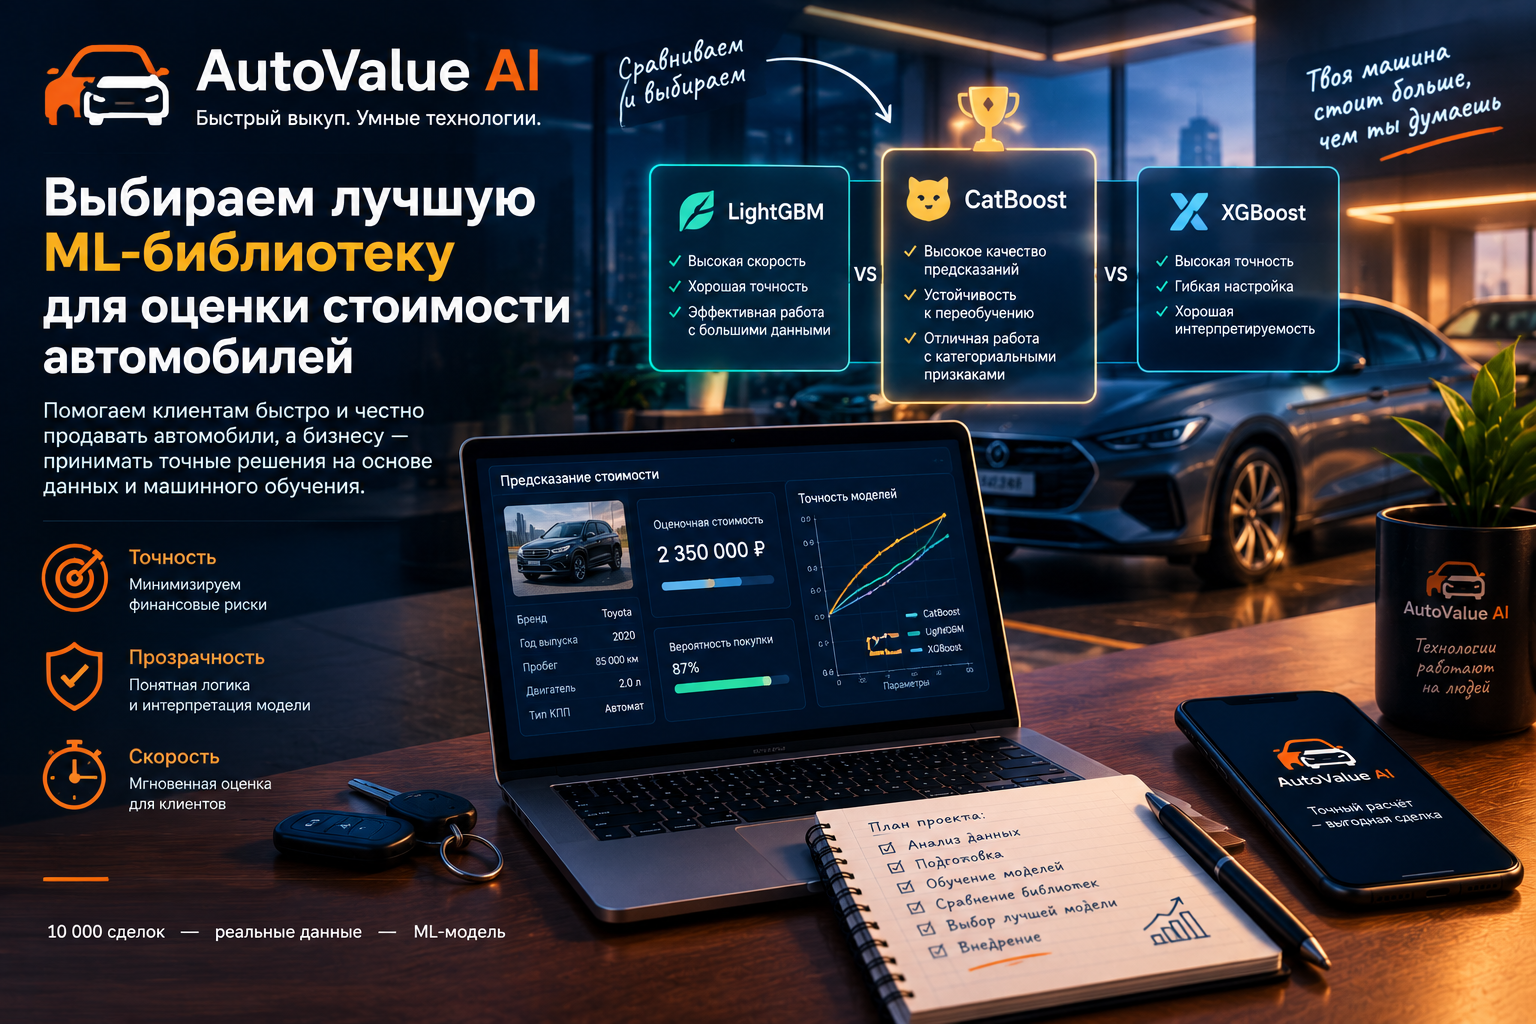

<a id='p1'></a>

---

## Цель и задачи проекта

### Цель проекта

Разработать модель машинного обучения для автоматической оценки рыночной стоимости подержанного автомобиля в рамках сервиса `AutoValue AI`.

Модель должна по характеристикам автомобиля предсказывать его рыночную стоимость в рублях. Основная задача проекта - провести «турнир библиотек» и определить, какая из трёх библиотек градиентного бустинга - `XGBoost`, `CatBoost` или `LightGBM` - позволяет получить наиболее эффективную модель с точки зрения как технических, так и бизнес метрик качества.

При выборе итоговой модели необходимо учитывать не только точность прогнозирования, но и финансовые последствия ошибок. Завышение цены более чем на 20% приводит к риску переплаты при покупке автомобиля, а сильное занижение цены может привести к потере клиента и потенциальной выручки. Поэтому итоговая модель должна обеспечивать приемлемый баланс между точностью, стабильностью и бизнес-рисками.

Дополнительным требованием является прозрачность работы модели: необходимо определить наиболее значимые признаки с помощью `SHAP` и проверить, соответствует ли поведение модели бизнес-логике.

### Задачи проекта

В рамках указанной цели необходимо решить задачу регрессии. Для этого требуется выполнить следующие шаги:

1. Провести первичный анализ структуры и качества данных.
2. Выполнить исследовательский анализ данных: изучить распределение целевой переменной, корреляции, пропуски и т.д.
3. Подготовить признаки для обучения моделей и выделить целевую переменную `price_rub`.
4. Сформировать одинаковые выборки для честного сравнения всех трёх библиотек.
5. Обучить базовые модели `XGBoost`, `CatBoost` и `LightGBM`.
6. Сравнить модели по техническим метрикам `RMSE`, `MAE`, `R²`.
7. Сравнить модели по бизнес-метрикам `Overpricing Rate` и `Underpricing Loss`.
8. Провести подбор гиперпараметров каждой модели с помощью `Optuna`.
9. Провести `SHAP`-анализ лучших моделей и определить наиболее значимые признаки.
10. Исследовать склонность моделей к завышению и занижению стоимости для разных марок автомобилей и регионов.
11. Выполнить финальную проверку лучшей оптимизированной модели на отложенной тестовой выборке `ds_s16_test_data.csv`.
12. Сформулировать итоговую рекомендацию по библиотеке, модели и гиперпараметрам для внедрения в `AutoValue AI`.

**Дополнительно** может быть проведено сравнение времени обучения и предсказания моделей, а также реализована квантильная регрессия в `CatBoost` для снижения риска завышения стоимости.

<a id='p2'></a>

---

## Постановка задачи машинного обучения

Задача проекта относится к **обучению с учителем** и является задачей **регрессии**. Для каждого автомобиля необходимо на основании его характеристик спрогнозировать рыночную стоимость в рублях. 

Целевая переменная:
- `price_rub` - рыночная стоимость автомобиля в рублях.

В качестве моделей для проведения «турнира библиотек» будут рассмотрены:
- `XGBoost` - библиотека градиентного бустинга над решающими деревьями;
- `CatBoost` - библиотека градиентного бустинга, хорошо работающая в том числе с категориальными признаками;
- `LightGBM` - библиотека градиентного бустинга с эффективным обучением деревьев по листьям.

Для всех трёх библиотек необходимо использовать одинаковые обучающие и валидационные выборки, чтобы сравнение моделей было корректным. При подготовке категориальных признаков следует учитывать особенности каждой библиотеки и использовать соответствующие ей методы обработки.

Отдельная тестовая выборка `ds_s16_test_data.csv` содержит 2 000 наблюдений и должна использоваться *исключительно для финальной оценки*. Она не должна участвовать в обучении моделей или подборе гиперпараметров.

### Метрики оценки

Качество моделей будет оцениваться с помощью технических и бизнес-метрик. Основные **технические метрики**:
- `MAE` - средняя абсолютная ошибка прогнозирования;
- `RMSE` - корень из среднеквадратичной ошибки;
- `R²` - коэффициент детерминации.

Основной метрикой для бизнес-сравнения является `MAE`, поскольку она показывает среднюю абсолютную ошибку непосредственно в рублях и поэтому легко интерпретируется бизнесом. Дополнительно используются две бизнес-метрики.

<span style="font-size: 16px;">**Overpricing Rate**</span>

Доля случаев, когда модель завысила стоимость автомобиля более чем на 20%:

$$
\text{Error Ratio} = \frac{y_{pred} - y_{true}}{y_{true}}, \qquad \text{Overpricing Rate} = (\text{Error Ratio} > 0.20).\text{mean()}
$$

Высокое значение этой метрики означает повышенный риск покупки автомобилей по завышенной цене.

<span style="font-size: 16px;">**Underpricing Loss**</span>

Суммарная упущенная выгода в случаях, когда модель занизила стоимость более чем на 20%:

$$
\text{Underpricing Loss} = \sum\limits_{\text{Error Ratio}<-0.2} y_{true}-y_{pred}
$$

Таким образом, при выборе лучшей модели необходимо учитывать одновременно:
- минимальную `MAE`;
- низкую `RMSE`;
- высокий `R²`;
- низкий `Overpricing Rate`;
- низкий `Underpricing Loss`.

### Подбор гиперпараметров

Для каждой из трёх библиотек необходимо провести оптимизацию гиперпараметров с помощью `Optuna`. Общая сетка параметров:

1. Скорость обучения `learning_rate` / `eta`: от `0.01` до `0.1`, `log=True`;
2. Глубина дерева `max_depth` / `depth`: от `3` до `10`;
3. Количество итераций `n_estimators` / `iterations`: от `500` до `2000`;
4. `random_seed = 42`;
5. Функция потерь - `MAE`.

Специфические параметры библиотек:

**XGBoost:**

* `gamma`: от `1e-8` до `1.0`;
* `reg_lambda` / `reg_alpha`: от `1e-8` до `10.0`.

**CatBoost:**

* `l2_leaf_reg`: от `1` до `10`.

**LightGBM:**

* `num_leaves`: от `20` до `256`;
* `min_child_samples`: от `5` до `100`;
* `reg_alpha` и `reg_lambda`: от `1e-8` до `1.0`.

Для каждой библиотеки необходимо определить лучшую версию модели по результатам оптимизации.

### Интерпретация модели

Для лучших моделей необходимо провести `SHAP`-анализ. Основные задачи интерпретации:
1. Определить топ-5 признаков, которые сильнее всего влияют на стоимость автомобиля.
2. Проверить, соответствует ли влияние признаков бизнес-логике.
3. Исследовать влияние менее очевидных признаков, например `color` и `insurance_valid`.
4. Проанализировать влияние количества ДТП `accidents_reported`.

Отдельно необходимо проанализировать ошибки моделей по:
- маркам автомобилей;
- макрорегионам.

Для каждой группы следует определить `Overpricing Rate` и `Underpricing Loss`, чтобы выявить сегменты, в которых модель систематически ошибается.

### Финальная проверка

После выбора лучшей оптимизированной модели необходимо провести её финальную оценку на `ds_s16_test_data.csv`. Результаты на тестовой выборке следует сравнить с результатами на валидационной выборке. Если значения метрик на валидации и финальном тесте отличаются *не более* чем примерно на **5–10%**, модель можно считать достаточно *стабильной* и не демонстрирующей выраженного переобучения.

### Описание данных

Для построения моделей предоставлены две выборки:
1. `ds_s16_train_data.csv` - 8 000 исторических сделок, используемых для обучения и валидации моделей.
2. `ds_s16_test_data.csv` - 2 000 наблюдений, предназначенных исключительно для финальной проверки выбранной модели.

Признаки:
* `brand` - марка автомобиля;
* `make_year` - год выпуска;
* `mileage_kmpl` - пробег;
* `engine_cc` - объём двигателя;
* `fuel_type` - тип топлива;
* `transmission` - тип коробки передач;
* `owner_count` - количество владельцев;
* `color` - цвет автомобиля;
* `service_history` - наличие сервисной книжки;
* `accidents_reported` - количество зафиксированных ДТП;
* `insurance_valid` - наличие действующей страховки;
* `region` - макрорегион продажи автомобиля;
* `price_rub` - целевая переменная, рыночная стоимость автомобиля.

Таким образом, итоговая задача проекта заключается в выборе наиболее эффективной библиотеки и модели для автоматической оценки автомобилей. При этом модель должна не только минимизировать среднюю ошибку прогнозирования, но и ограничивать финансовые риски компании, связанные с завышением или занижением цены, а также быть достаточно прозрачной для бизнес-интерпретации.


<a id='contents'></a>

---

<span style="font-size: 18px;">**Оглавление**</span>

1. [Цель и задачи проекта](#p1)
2. [Постановка задачи машинного обучения](#p2)
3. Исследовательский анализ данных (EDA)
    - [Загрузка библиотек и данных](#p3a)
    - [Проверка на пропуски, дубликаты, аномалии](#p3b)
    - [Корреляция](#p3c)
    - [Выводы по EDA](#p3d)
4. Обучение и валидация базовых моделей
    - [Описание моделей](#p4a)
    - [Сопоставление по метрикам](#p4b)
5. [Подбор гиперпараметров моделей](#p5)
6. Интерпретация и бизнес-анализ
    - [Анализ влияния признаков](#p6a)
    - [Анализ распределения ошибки по разным разным регионам и маркам](#p6b)
7. [Финальная модель](#p7)
8. [Аналитическая записка проекту AutoValue AI](#p8)
9. [Расширенные выводы и рекомендации](#p9)

<a id='p3a'></a>

---

## Исследовательский анализ данных (EDA)

Проведем краткое исследование, чтобы лучше понимать данные.

### Загрузка библиотек и данных

Загрузим данные из файлов и оценим их содержимое.

[К Содержимому проекта](#contents)

In [1]:
# Установка библиотек
# !pip install optuna -Uq

# try:
#     !pip freeze > "../requirements.txt"
# except Exception:
#     !pip freeze > "requirements.txt"

In [2]:
# Основные библиотеки для работы с датафреймами, визуализацией, а также вспомогательные
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import joblib
from time import time
import sys

# Модели
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

# Разделение на фолды
from sklearn.model_selection import train_test_split

# Поиск гиперпараметров
import optuna
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

# Оценка важности признаков
import shap

# Метрики
from sklearn.metrics import ( 
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score 
)

# Оценка корреляции
from phik import phik_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [3]:
# Фиксирую состояние и дополнительный класс для более качественного вывода
random_state = 42
class color:
    """
    Класс для форматирования текста в терминале
    """

    PURPLE = "\033[95m"
    CYAN = "\033[96m"
    DARKCYAN = "\033[36m"
    BLUE = "\033[94m"
    GREEN = "\033[92m"
    YELLOW = "\033[93m"
    RED = "\033[91m"
    BOLD = "\033[1m"
    UNDERLINE = "\033[4m"
    END = "\033[0m"  # сбросить все стили (возврат к нормальному виду)

def root_mean_squared_error(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

In [4]:
try:
    df_train = pd.read_csv('./../datasets/ds_s16_train_data.csv')
    df_test = pd.read_csv('./../datasets/ds_s16_test_data.csv')
except FileNotFoundError:
    df_train = pd.read_csv('/datasets/ds_s16_train_data.csv')
    df_test = pd.read_csv('/datasets/ds_s16_test_data.csv')

In [5]:
print(color.BOLD + color.BLUE + 'Случайные пять строк тренировочной выборке:' + color.END)
display(df_train.sample(n=5, random_state = random_state))

print(color.BOLD + color.RED + '\nОсновая информация по датасету:\n' + color.END)
df_train.info()

print(color.BOLD + color.GREEN + '\nСтатистическая информация по датасету:\n' + color.END)
display(df_train.describe().T)
display(df_train.select_dtypes(include=["object", "string", "category"]).describe().T)

Случайные пять строк тренировочной выборке:


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
2215,2011,13.65,5000,Petrol,3,Volkswagen,Manual,Black,Unknown,1,Yes,1141865,Дальний Восток
2582,2004,6.18,2500,Petrol,2,Honda,Automatic,Silver,Unknown,0,Yes,663249,Москва
1662,2001,22.14,5000,Petrol,4,Tesla,Automatic,Red,Partial,0,Yes,813337,Дальний Восток
3027,2017,17.84,3000,Petrol,2,Chevrolet,Automatic,Black,Partial,1,Yes,948732,Урал
4343,2016,13.72,2500,Petrol,2,Kia,Manual,Blue,Full,1,Yes,901438,Дальний Восток



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   str    
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   str    
 6   transmission        8000 non-null   str    
 7   color               8000 non-null   str    
 8   service_history     8000 non-null   str    
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   str    
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 812.6 KB

Статистическая информация по датасету:



,count,mean,std,min,25%,50%,75%,max
make_year,8000.0,2009.221250,8.388703,1995.0,2002.00,2009.00,2017.00,2023.0
mileage_kmpl,8000.0,17.946343,5.015565,5.0,14.53,17.97,21.35,35.0
engine_cc,8000.0,2289.687500,1289.812139,800.0,1200.00,2000.00,3000.00,5000.0
owner_count,8000.0,3.001125,1.419199,1.0,2.00,3.00,4.00,5.0
accidents_reported,8000.0,0.487875,0.693839,0.0,0.00,0.00,1.00,5.0
price_rub,8000.0,683647.872125,264923.498564,95000.0,493857.00,663866.00,855056.00,1676525.0


,count,unique,top,freq
fuel_type,8000,3,Petrol,3990
brand,8000,10,Nissan,870
transmission,8000,2,Manual,4812
color,8000,6,White,1366
service_history,8000,3,Full,3985
insurance_valid,8000,2,Yes,6356
region,8000,6,Юг,1408


In [6]:
print(color.BOLD + color.BLUE + 'Случайные пять строк тестовой выборки:' + color.END)
display(df_test.sample(n=5, random_state = random_state))

print(color.BOLD + color.RED + '\nОсновая информация по датасету:\n' + color.END)
df_test.info()

print(color.BOLD + color.GREEN + '\nСтатистическая информация по датасету:\n' + color.END)
display(df_test.describe().T)
display(df_test.select_dtypes(include=["object", "string", "category"]).describe().T)

Случайные пять строк тестовой выборки:


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
1860,2018,22.32,2000,Petrol,1,Honda,Manual,Blue,Full,1,Yes,662660,Урал
353,2011,16.98,2500,Diesel,5,Tesla,Manual,Gray,Partial,1,No,519884,Дальний Восток
1333,2011,18.07,800,Petrol,5,Honda,Manual,White,Partial,2,Yes,339193,Юг
905,2021,21.26,1000,Petrol,4,Tesla,Manual,Black,Partial,0,Yes,742191,СПб
1289,2021,17.28,1800,Diesel,1,Tesla,Automatic,Silver,Full,0,Yes,697615,СПб



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   str    
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   str    
 6   transmission        2000 non-null   str    
 7   color               2000 non-null   str    
 8   service_history     2000 non-null   str    
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   str    
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 203.3 KB

Статистическая информация по датасету:



,count,mean,std,min,25%,50%,75%,max
make_year,2000.0,2009.149500,8.316052,1995.0,2002.00,2009.000,2016.0000,2023.00
mileage_kmpl,2000.0,18.018395,5.065829,5.0,14.57,18.005,21.3825,34.38
engine_cc,2000.0,2276.900000,1297.392772,800.0,1200.00,1800.000,3000.0000,5000.00
owner_count,2000.0,3.013000,1.418040,1.0,2.00,3.000,4.0000,5.00
accidents_reported,2000.0,0.509500,0.695091,0.0,0.00,0.000,1.0000,4.00
price_rub,2000.0,675791.935500,268019.598864,95000.0,481477.00,649284.000,845969.5000,1629774.00


,count,unique,top,freq
fuel_type,2000,3,Petrol,978
brand,2000,10,Tesla,222
transmission,2000,2,Manual,1173
color,2000,6,Gray,365
service_history,2000,3,Full,1002
insurance_valid,2000,2,Yes,1578
region,2000,6,Сибирь,357


In [7]:
for col in df_train.select_dtypes(include=["object", "string", "category"]):
    print(color.BOLD + color.BLUE + '\nУникальные значения в колонке ' + col + ' тренеровочный датафрейм:\n' + color.END)
    print(sorted(df_train[col].unique()))
    
    print(color.BOLD + color.RED + '\nУникальные значения в колонке ' + col + ' тестовый датафрейм:\n' + color.END)
    print(sorted(df_test[col].unique()))


Уникальные значения в колонке fuel_type тренеровочный датафрейм:

['Diesel', 'Electric', 'Petrol']

Уникальные значения в колонке fuel_type тестовый датафрейм:

['Diesel', 'Electric', 'Petrol']

Уникальные значения в колонке brand тренеровочный датафрейм:

['BMW', 'Chevrolet', 'Ford', 'Honda', 'Hyundai', 'Kia', 'Nissan', 'Tesla', 'Toyota', 'Volkswagen']

Уникальные значения в колонке brand тестовый датафрейм:

['BMW', 'Chevrolet', 'Ford', 'Honda', 'Hyundai', 'Kia', 'Nissan', 'Tesla', 'Toyota', 'Volkswagen']

Уникальные значения в колонке transmission тренеровочный датафрейм:

['Automatic', 'Manual']

Уникальные значения в колонке transmission тестовый датафрейм:

['Automatic', 'Manual']

Уникальные значения в колонке color тренеровочный датафрейм:

['Black', 'Blue', 'Gray', 'Red', 'Silver', 'White']

Уникальные значения в колонке color тестовый датафрейм:

['Black', 'Blue', 'Gray', 'Red', 'Silver', 'White']

Уникальные значения в колонке service_history тренеровочный датафрейм:

['Ful

Основные выводы будут описаны [далее](#p3d). Загрузка прошла успешно, аномалий не заметно, типы определены в целом корректно, однако, необходимо преобразования перед запуском моделей.

<a id='p3b'></a>

---

### Проверка на пропуски, дубликаты, аномалии

Исходя из предварительного анализа при загрузки стоит отметить отсутствие явных пропусков, аномальных значений в категориальных значениях. Оценим распределения в целевой переменной и других столбцах, а также проверим на дубликаты. Оценка будет производится исключительно на тренировочных данных. Начнем с дубликатов.

[К Содержимому проекта](#contents)

In [8]:
display(df_train[df_train.duplicated(subset=['make_year', 'mileage_kmpl', 
                                             'brand', 'fuel_type', 'region'], keep=False)].sort_values(by=['make_year', 'mileage_kmpl'], ascending=False))

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
2189,2021,20.17,1800,Petrol,4,Honda,Manual,Black,Full,0,Yes,632617,Дальний Восток
2192,2021,20.17,1000,Petrol,2,Honda,Manual,White,Full,1,Yes,1018606,Дальний Восток
4036,2021,19.98,1500,Petrol,2,Ford,Manual,Silver,Full,0,Yes,832223,СПб
5095,2021,19.98,2500,Petrol,2,Ford,Automatic,Silver,Full,1,Yes,884519,СПб
7062,2021,5.00,2000,Petrol,1,Toyota,Manual,Red,Full,0,Yes,853926,Юг
7609,2021,5.00,1000,Petrol,3,Toyota,Automatic,Blue,Unknown,0,Yes,542068,Юг
3333,2017,17.10,5000,Petrol,2,BMW,Manual,White,Full,0,Yes,1191658,Дальний Восток
4051,2017,17.10,2500,Petrol,1,BMW,Manual,Red,Full,0,Yes,835109,Дальний Восток


Дубликатов не заметно. Оценим распределения признаков:

In [9]:
# Подпрограмма для визуализации распределения признаков
def plot_cat_num_target(df_in, type_f = 'Num', target_dict = None, exclude_cols=None, figsize=(15, 15), ncols=3):
    df = df_in.copy()
    
    if type_f == 'Num':
        bools_list = list(df.select_dtypes(include = ['boolean']).columns)
        df[bools_list] = df[bools_list].astype(int)
        cols = list(df.select_dtypes(include = ['int', 'float']).columns)
    elif type_f == 'Cat':
        cols = list(df.select_dtypes(include = ['object', 'category', 'string']).columns)
    if exclude_cols:
            cols = [col for col in cols if col not in exclude_cols]
    
    
    if target_dict is None:
        if type_f == 'Num':
            df[cols].hist(figsize = figsize)
            plt.show()
        elif type_f == 'Cat':
            n_feat = len(cols)
            nrows = math.ceil(n_feat / ncols)
            fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
            for k, col in enumerate(cols):
                i, j = divmod(k, ncols)
                ax = axes[i, j]
                df[col].value_counts(dropna=False).plot.barh(ax=ax, edgecolor='black')
                ax.set_title(col, fontsize=12)
                ax.set_xlabel('Количество')
                ax.set_ylabel('')
            plt.show()
    else:
        name_t = target_dict['name_t']
        type_t = target_dict['type_t']
        
        if (type_f == 'Cat') and (type_t == 'Cat'):
            cols.remove(name_t)
            n_feat = len(cols)
            nrows = math.ceil(n_feat / ncols)
            
            fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
            for k, col in enumerate(cols):
                i, j = divmod(k, ncols)
                ax = axes[i, j]
                ctab = pd.crosstab(df[col], df[name_t], dropna=False)
                
                ctab.plot.barh(ax=ax, legend=False, edgecolor='black')
                ax.set_title(col, fontsize=12)
                ax.set_xlabel('Количество')
                ax.set_ylabel(col)
            
            handles, labels = ax.get_legend_handles_labels()
            fig.legend(handles, labels, title=target_col, loc='upper right', bbox_to_anchor=(1.0, 1.0))
            plt.tight_layout()
            plt.show()
            
        else:
            sns.set_context("notebook", font_scale=1.0)
            if name_t in cols:
                cols.remove(name_t)
            
            for col in cols:
                g = sns.jointplot( data=df, x=col, y=name_t, height=4,
                                  marginal_kws={'linewidth': 1, 'edgecolor': 'black', 'alpha': 0.5},
                                  joint_kws={'s': 40, 'alpha': 0.5, 'edgecolor': 'none'})
                g.set_axis_labels(col, name_t, fontsize=12)
                g.ax_joint.grid(True, alpha=0.3)
                
                for patch in g.ax_marg_x.patches:
                    patch.set_linewidth(1.5)
                    patch.set_edgecolor('black')
                for patch in g.ax_marg_y.patches:
                    patch.set_linewidth(1.5)
                    patch.set_edgecolor('black')
                
                plt.show()

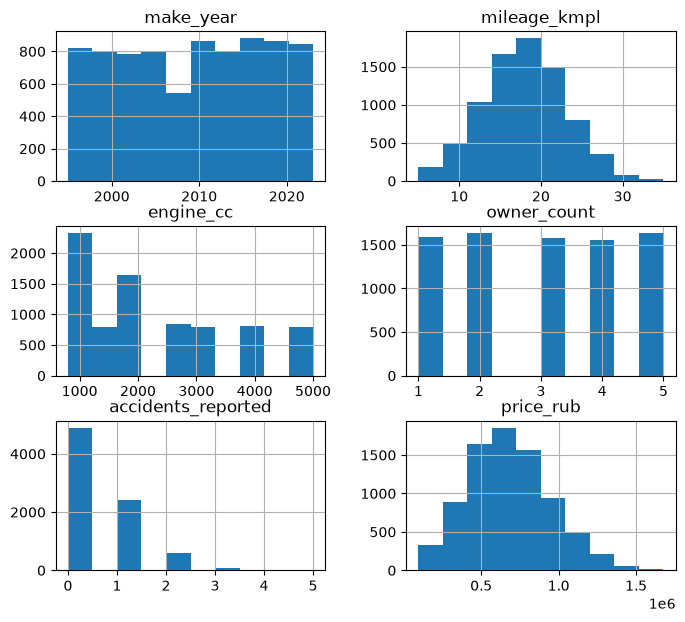

In [10]:
plot_cat_num_target(df_train, type_f = 'Num', figsize=(8, 7), ncols=3)

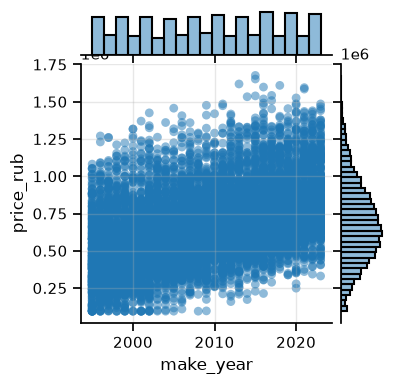

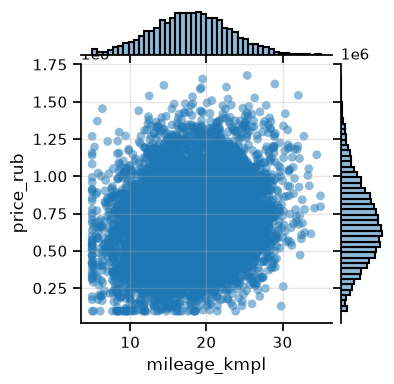

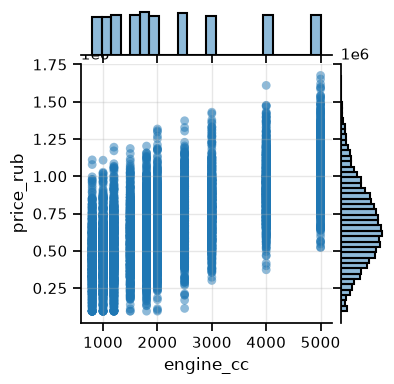

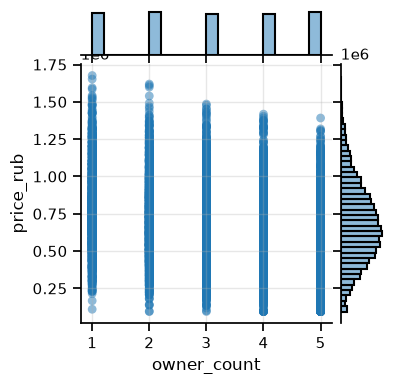

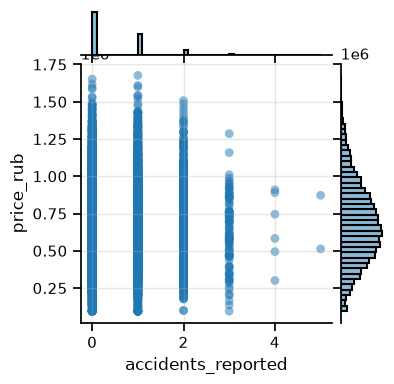

In [11]:
plot_cat_num_target(df_train, type_f = 'Num', target_dict = {'name_t':'price_rub', 'type_t':'Num'}, figsize=(12, 12), ncols=3)

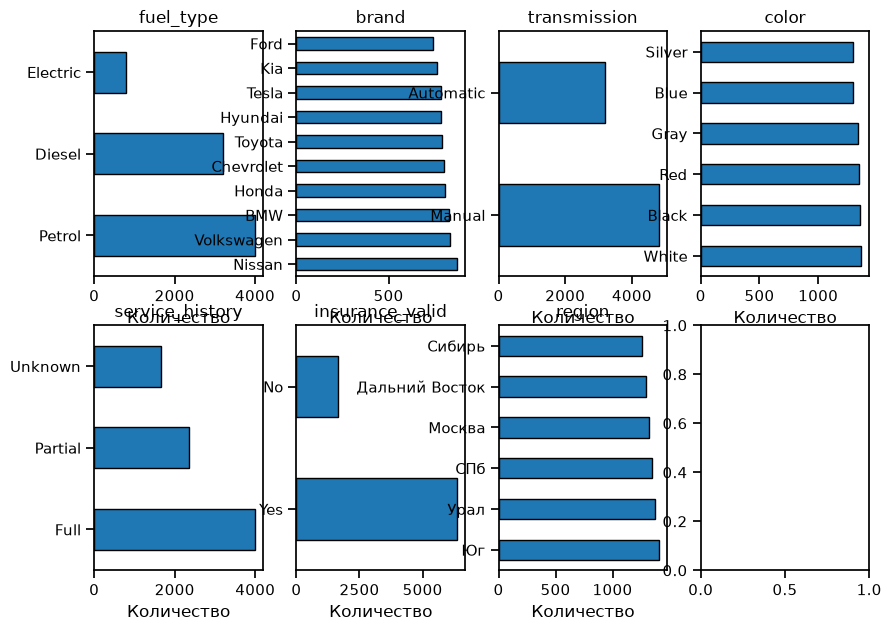

In [12]:
plot_cat_num_target(df_train, type_f = 'Cat', figsize=(10, 7), ncols=4)

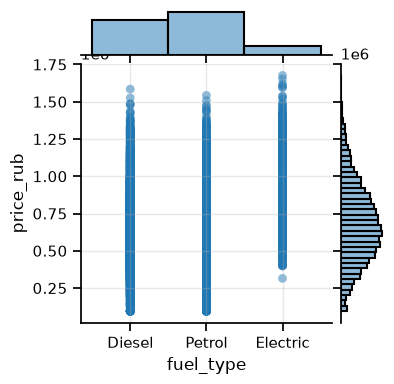

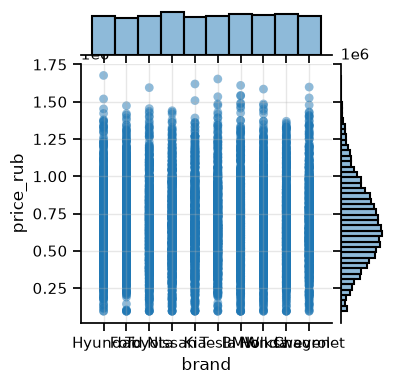

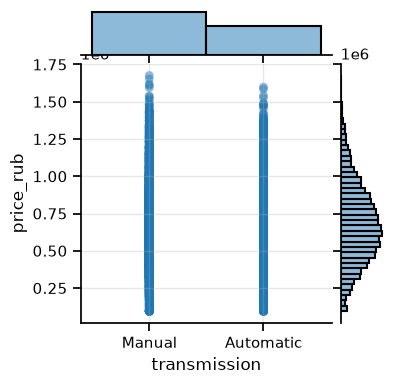

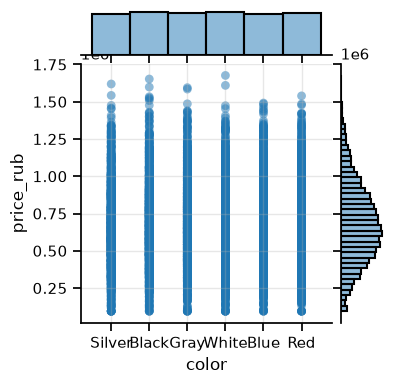

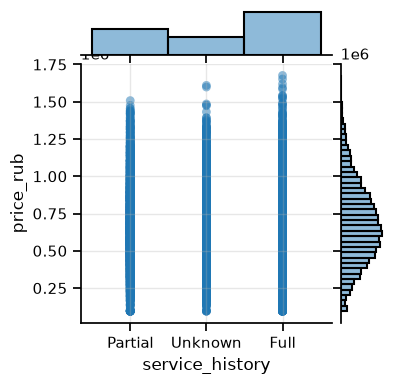

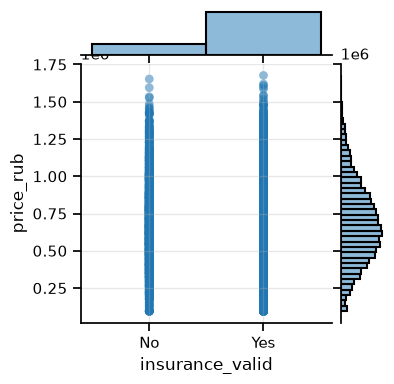

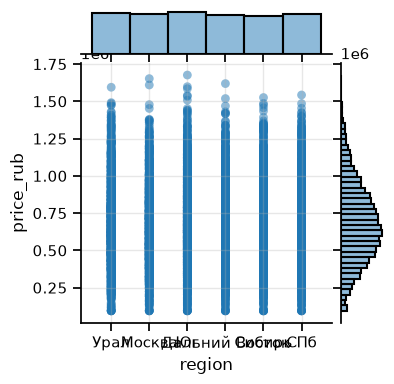

In [13]:
plot_cat_num_target(df_train, type_f = 'Cat', target_dict = {'name_t':'price_rub', 'type_t':'Num'}, figsize=(12, 12), ncols=3)

Основные выводы будут описаны [далее](#p3d). Ярко выраженных выбросов, аномалий в целевой переменной и в признаках не заметно. Для целевой переменной заметен небольшой скос вправо к большим значениям стоимости машин. Заметна сильная связь между целевой переменной и признаками (категориальными или не числовыми).

<a id='p3c'></a>

---

### Корреляция

[К Содержимому проекта](#contents)

In [14]:
def plot_heatmap(data,title,xlabel,ylabel,figsize = (4,4)):
    plt.figure(figsize=figsize)
    fig = sns.heatmap(data,
                      annot=True, # Отображаем численные значения в ячейках карты
                      fmt='.2f', # Форматируем значения корреляции: два знака после точки
                      cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
                      linewidths=0.5, # Форматируем линию между ячейками карты
                      cbar=False # Отключаем цветовую шкалу
                      ,annot_kws={'size': 8}
                      ,mask = np.triu(np.ones_like(data, dtype=bool))
                     )
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=10)
    plt.ylabel(ylabel, fontsize=10)

    fig.tick_params(axis='both', labelsize=8)    
    
    plt.show()

In [15]:
num_cols = list(df_train.select_dtypes(include=['int', 'float']).columns)
cat_cols = list(df_train.select_dtypes(include=["object", "string", "category"]).columns)

correlation_matrix_phik = df_train.phik_matrix(interval_cols = num_cols)
correlation_matrix_pearson = df_train[num_cols].corr(method='pearson')
correlation_matrix_spearman = df_train[num_cols].corr(method='spearman')

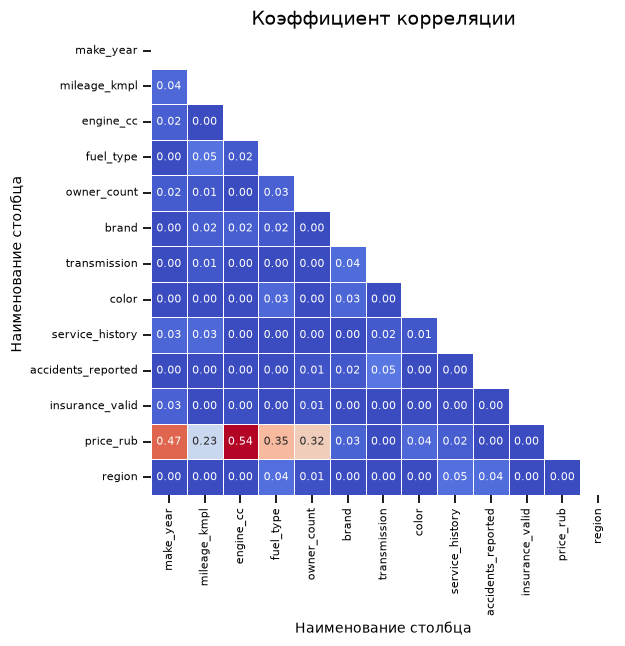

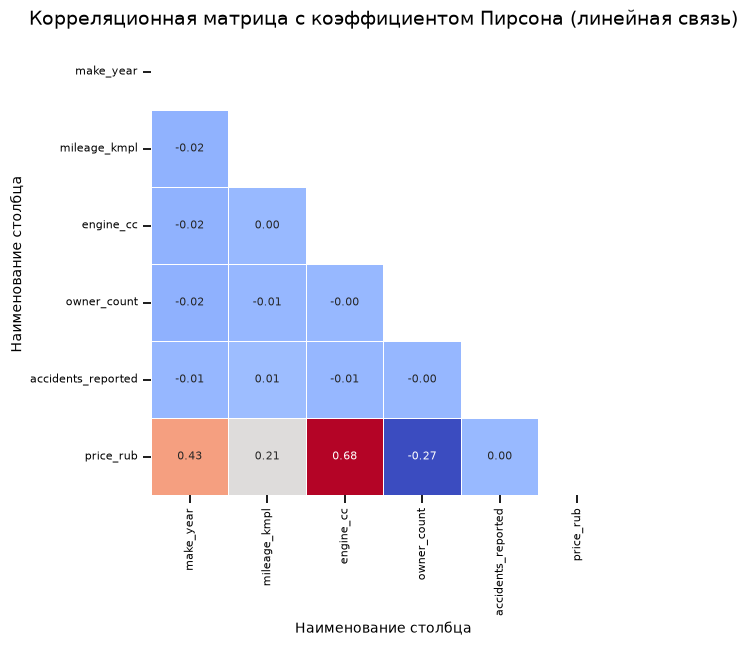

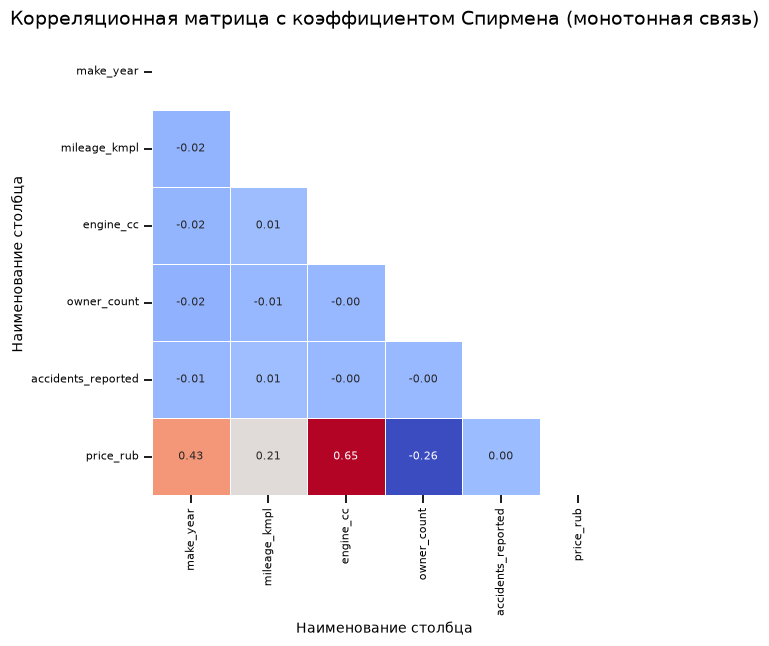

In [16]:
plot_heatmap(correlation_matrix_phik,'Коэффициент корреляции','Наименование столбца'
             ,'Наименование столбца',figsize = (6,6))
plot_heatmap(correlation_matrix_pearson,'Корреляционная матрица с коэффициентом Пирсона (линейная связь)'
             ,'Наименование столбца','Наименование столбца',figsize = (6,6))
plot_heatmap(correlation_matrix_spearman,'Корреляционная матрица с коэффициентом Спирмена (монотонная связь)'
             ,'Наименование столбца','Наименование столбца',figsize = (6,6))

Для проверки на мультиколлинеарность используется коэффициент variance_inflation_factor (VIF). В рамках данного коэффициент для каждого признака строится регрессия этого признака на все остальные признаки. Если остальные признаки хорошо объясняют его значение, VIF получается большим - это признак мультиколлинеарности.

У VIF есть формула: $ \text{VIF} = \frac{1}{1-R^2_i}$. Здесь $R^2_i$ - коэффициент детерминации при регрессии i-го признака на все остальные признаки.

Традиционно, показатель значения показателя оценивают примерно так: 
- VIF $\approx$ 1 - мультиколлинеарности практически нет
- VIF $\in(1,5)$ допустимый уровень
- VIF $\in[5,10]$ заметная мультиколлинеарность
- VIF > 10 сильная мультиколлинеарность

In [17]:
Xpr = df_train.drop(columns=['price_rub'] + cat_cols).copy()
Xpr = add_constant(Xpr)
vif = pd.DataFrame({
    'feature': Xpr.columns,
    'VIF': [
        variance_inflation_factor(Xpr.values, i)
        for i in range(Xpr.shape[1])
    ]
})
vif = vif.sort_values('VIF', ascending=False)
display(vif)

,feature,VIF
0,const,57567.966929
1,make_year,1.001562
4,owner_count,1.000672
2,mileage_kmpl,1.000588
3,engine_cc,1.000491
5,accidents_reported,1.000229


Основные выводы [ниже](#p3d). Здесь опишу часть наблюдений в полученных результатах. Заметна связь между целевой переменной и частью признаков, что поможет в дальнейшем при предсказании значения переменной. Линейной мультиколлинеарности между числовыми признаками нет.

<a id='p3d'></a>

---

### Выводы по EDA

[К Содержимому проекта](#contents)

Тренировочная выборка состоит из 8000 записей, а тестовая из 2000. Имена столбцов соответствуют стандарту, принятому в python. Типы столбцов выбраны верно, однако, допустима оптимизация. Например, `insurance_valid` принимает строковые значения 'yes', 'no', хотя здесь оптимальным является значение - 1 и 0. Аналогичные рассуждения применимы для типа трансмиссии `transmission`, т.к. их все две - 'Automatic', 'Manual' (можно также закодировать одну из них через 1, а другую через 0). Различий между категориями значений в тестовой и тренировочной выборке не замечено. Уникальных категорий для некоторой из выборок нет ни в одном из признаков. Пропусков или аномальных значений в столбцах тренировочной или тестовой выборки не замечено. Дубликаты и выбросы также не замечены.

Рассматривая распределения признаков, корреляцию с целевой переменной `price_rub` можно заметить следующее:
1. Признак `make_year`, год выпуска. Данный признак странен сам по себе и может включать два смысла в одном значении. С одной стороны год выпуска характеризует возраст автомобиля (который желательно рассматривать в качестве самостоятельного признака, однако непонятно какой год выбирать в качестве сейчас). С другой стороны данный показатель характеризует модель автомобиля, например `Toyota Camry` 2016 года выпуска и `Toyota Camry` 2020 года выпуска достаточно разные машины, что может повлиять на стоимость. Рассматривая распределение, заметна аномалия вблизи 2008 и 2009 года выпуска (машин заметно меньше). Данная аномалия, возможно, связана с экономическими условиями (финансовый кризис), что привело к падению производства машин в эти года. Анализирую связь с целевой переменной графически и на основании коэффициента корреляции заметна линейная связь - чем позже машина произведена, тем меньше цена и наоборот. Это подтверждается как графически (заметна линия), так и на основании коэффициентов корреляции $\varphi_k$ и коэффициентов Спирмена и Пирсона.
2. Признак `mileage_kmpl`, пробег. Ярко выраженных аномалий в распределение не заметно, оно практически нормальное. Коэффициенты корреляции подсвечивают слабую положительную связь между целевой переменной и пробегом - чем меньше пробег, тем меньше цена и наоборот. Анализирую график зависимости наличие связи можно подтвердить, хотя и с некоторыми оговорками, в отличии от предыдущего случая. Сами значения в этом столбце достаточно странные, непонятно в чем измеряется показатель, как он рассчитывается. Требуется дополнительные уточнения у заказчика.
3. Признак `engine_cc`, объём двигателя. Графически и исходя из коэффициента корреляции между ним и целевой переменной заметна наиболее сильная связь по всем трем коэффициентов. Обычно более мощные двигатели устанавливаются на премиальные автомобили, что подсвечивает графики и коэффициент корреляции. В целом в выборке присутствуют как дорогие марки с высоким объемом двигателя, так и бюджетные машины (их скорее всего больше). Странным, пожалуй, является наличие данного показателя для электромобилей. Возможно, рассматриваются гибриды, либо какие-то другие показатели, которые позволяют сравнивать машины между собой.
4. Признак `fuel_type`, тип топлива. Категориальный признак. В целом заметна корреляция между данным показателем и целевой переменной. В частности, для электричек цена выше в среднем, чем для других видов машин. Однако, данные автомобили редко встречаются. 
5. Признак `owner_count`, количество владельцев. Заметна отрицательная связь с целевой переменной - чем больше владельцев, тем ниже цена. Автомобили в целом достаточно равномерно распределены по количеству владельцев (количество машин с одним владельцем примерно равно количеству машин с 5 владельцами).
6. Признак `brand`, марка автомобиля. В целом представлены автомобили разных брендов, наименее распространенный - 'Ford', а наиболее распространённый - 'Nissan'. Данные распределены достаточно равномерно по брендам. Влияние на цену для некоторых брендов заметно на графиках, однако, коэффициенты корреляции практически равны нулю, что означает отсутствие корреляции.
7. Признак `transmission`, тип коробки передач. Машин с механической коробкой передач слегка больше, чем с автоматической. Анализирую связь с целевой переменной как графически, так и через коэффициент корреляции - сложно выявить связь с целевой переменной.
8. Признак `color`, цвет кузова. Машины распределены по цветам достаточно равномерно. Ярко выраженного влияние на целевую переменную не обнаружено.
9. Признак `service_history`, наличие сервисной книжки. В большинстве случаев имеется полная история об автомобиле. В районе 30% случаев история частичная и у 20% автомобилей история неизвестна. Коэффициенты корреляции с целевой переменной близки к нулю. Графически сильное влияние не заметно.
10. Признак `accidents_reported`, количество зафиксированных ДТП. Заметно влияние на целевую переменную графически. Однако, сильного влияния в рамках коэффициента корреляции не обнаружено. Распределение заметно растянуто вправо - большинство машин не попадали в ДТП.
11. Признак `insurance_valid`, действительна ли страховка. В большинстве случаев страховка действительна. Сильного влияния графически или в рамках коэффициентов корреляции не заметно.
12. Признак `region`, макрорегион РФ. Машины достаточно равномерно распределены по разным регионам РФ. Ярко выраженного влияния на целевую переменную не заметно.
13. Связь признаков между собой (как попарная, так и мультиколлинеарная) не заметна.

<a id='p4a'></a>

---

## Обучение и валидация базовых моделей

### Описание моделей

[К Содержимому проекта](#contents)

Опишем вспомогательные подпрограммы и программы для расчета бизнес-метрик. В рамках предобработки приведем к нужным типам данных, а также создадим списки категориальных признаков для соответствующих алгоритмов градиентного бустинга. Кроме того, проведем разделение на тренировочные и валидационные данные для подбора гиперпараметров. В данном случае применяется именно такой способ разделения, а не кросс-валидация для ускорения подбора параметров по всем моделям бустинга. Данных в принципе достаточно.

Обучим четыре модели на стандартных настройках и оценим время на обучение:
1. XGBoost.
2. LightGBM.
3. CatBoost.
4. Осторожный CatBoost c квантильным лоссом.

---

#### Вспомогательные подпрограммы

In [18]:
def overpricing_rate(y_true, y_pred, threshold = 0.2):
    error_ratio = (y_pred - y_true) / y_true
    return (error_ratio > threshold).mean()

def underpricing_rate(y_true, y_pred, threshold = -0.2):
    error_ratio = (y_pred - y_true) / y_true
    return (error_ratio < threshold).mean()

def overpricing_loss(y_true, y_pred, threshold = 0.2):
    error_ratio = (y_pred - y_true) / y_true
    over_mask = error_ratio > threshold
    return (y_pred[over_mask] - y_true[over_mask]).sum()

def underpricing_loss(y_true, y_pred, threshold = -0.2):
    error_ratio = (y_pred - y_true) / y_true
    under_mask = error_ratio < threshold
    return (y_true[under_mask] - y_pred[under_mask]).sum()

def metrics_dict_calc(y_true, y_pred, threshold_or = 0.2, threshold_ul = -0.2):
    return {
        'overpricing_rate' : overpricing_rate(y_true, y_pred, threshold_or),
        'underpricing_loss' : underpricing_loss(y_true, y_pred, threshold_ul),
        'overpricing_loss': overpricing_loss(y_true, y_pred, threshold_or),
        'MAE' : mean_absolute_error(y_true, y_pred),
        'R2' : r2_score(y_true, y_pred),
        'RMSE' : root_mean_squared_error(y_true, y_pred),
        'MAPE' : mean_absolute_percentage_error(y_true, y_pred) * 100,
        'MSE' : mean_squared_error(y_true, y_pred)
    }
# Type_Corrector преобразование типов и части столбцов
def Type_Corrector(X_train):
    X = X_train.copy()
    X['transmission'] = (X['transmission'] == 'Automatic').astype(int)
    X['insurance_valid'] = (X['insurance_valid'] == 'Yes').astype(int)
    
    for col in  X.select_dtypes(include = ['str','object']).columns.tolist():
        X[col] = X[col].astype('category')
    return X

# Функция для валидации модели по метрикам
def model_validate(model, X_train, y_train, X_val, y_val, model_name = 'Unknown', fold_name = 'Validation fold'):
    if 'XGBoost' in model_name:
        start_time = time()
        model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
        elapsed_fit = time() - start_time
    
    elif 'LightGBM' in model_name:
        start_time = time()
        model.fit(X_train, y_train, eval_X=(X_train, X_val), eval_y=(y_train, y_val),
                  eval_metric="mae", callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False),
                                                lgb.log_evaluation(period=0)])
        # categorical_feature=cat_columns, в документации вроде бы не надо
        elapsed_fit = time() - start_time
    
    elif 'CatBoost' in model_name:
        start_time = time()
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], cat_features=cat_list,
                  use_best_model=True, verbose=False)
        # categorical_feature=cat_columns, в документации вроде бы не надо
        elapsed_fit = time() - start_time
    
    start_time = time()
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    elapsed_predict = time() - start_time
    
    dict1 = {
        'Model name' : model_name,
        'Fold name' : 'Train fold',
        'Time elapsed fit' : elapsed_fit,
        'Time elapsed predict' : elapsed_predict,
        **metrics_dict_calc(y_train, y_train_pred)
    }
    
    dict2 = {
        'Model name' : model_name,
        'Fold name' : fold_name,
        'Time elapsed fit' : elapsed_fit,
        'Time elapsed predict' : elapsed_predict,
        **metrics_dict_calc(y_val, y_val_pred)
    }
    
    return [dict1, dict2]

# Для визуального подтверждения
def plot_MAE_train_val(x, y1, y2, figsize = (4, 4), 
                       label1 = 'MAE на обучающей выборке', label2 = 'MAE на валидационной выборке',
                       title = 'График зависимости значения MAE на обучающей/валидационной выборках'):
    plt.figure(figsize=figsize)
    plt.plot(x, y1, label=label1)
    plt.plot(x, y2, label=label2)
    plt.xlabel('Кол-во итераций')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [19]:
df_train = Type_Corrector(df_train)
cat_list = df_train.select_dtypes(include = ['category']).columns.tolist()

X_train_val = df_train.drop(columns = ['price_rub']).copy()
y_train_val = df_train['price_rub']

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=random_state)

---

#### Обучение моделей со стандартными настройками

Для модели `CatBoostRegressor_alpha` указано оптимальное значение. Логика выбора этого значения будет описана позднее.

In [20]:
# Инициализируем XGBoost
xgb_model = XGBRegressor(random_state=random_state,
                         enable_categorical=True,
                         eval_metric="mae", # задаём метрику для оценки качества обучения
                         early_stopping_rounds=20, # если 20 итераций подряд нет улучшения MAE на val — останавливаемся
                         n_jobs=-1
                        )

# Инициализируем LightGBM
lgbm_model = lgb.LGBMRegressor(random_state=random_state, 
                               n_jobs=-1,
                               verbose=-1)

# Инициализируем CatBoostRegressor
catb_model = CatBoostRegressor(random_state=random_state, 
                               thread_count=-1,
                               early_stopping_rounds=20,
                               eval_metric='MAE',
                               use_best_model=True
                               )

# Инициализируем CatBoostRegressor_alpha
alpha = 0.38
catb_model_alpha = CatBoostRegressor(random_state=random_state, 
                                     thread_count=-1,
                                     early_stopping_rounds=20,
                                     use_best_model=True,
                                     loss_function=f'Quantile:alpha={alpha}',
                                     eval_metric=f'Quantile:alpha={alpha}'
                                    )

<a id='p4b'></a>

---

### Сопоставление по метрикам

[К Содержимому проекта](#contents)

In [21]:
val_list = []
val_list = val_list + model_validate(xgb_model, X_train, y_train, X_val, y_val, 'XGBoost', 'Validation fold')
val_list = val_list + model_validate(lgbm_model, X_train, y_train, X_val, y_val, 'LightGBM', 'Validation fold')
val_list = val_list + model_validate(catb_model, X_train, y_train, X_val, y_val, 'CatBoost', 'Validation fold')
val_list = val_list + model_validate(catb_model_alpha, X_train, y_train, X_val, y_val, 'CatBoost_alpha', 'Validation fold')

display(pd.DataFrame(val_list).round(3).sort_values(by=['Fold name', 'MAE']))

,Model name,Fold name,Time elapsed fit,Time elapsed predict,overpricing_rate,underpricing_loss,overpricing_loss,MAE,R2,RMSE,MAPE,MSE
0,XGBoost,Train fold,1.522,0.007,0.114,3.926097e+07,9.294794e+07,64001.031,0.907,81316.883,12.048,6.612435e+09
2,LightGBM,Train fold,0.076,0.012,0.120,4.099319e+07,9.774562e+07,66370.514,0.901,83553.715,12.377,6.981223e+09
4,CatBoost,Train fold,4.493,0.007,0.132,5.558129e+07,1.171450e+08,73587.805,0.879,92398.886,13.638,8.537554e+09
6,CatBoost_alpha,Train fold,11.761,0.010,0.089,1.075036e+08,7.256288e+07,75750.603,0.869,96414.540,13.159,9.295764e+09
5,CatBoost,Validation fold,4.493,0.007,0.133,1.649226e+07,3.169333e+07,79548.802,0.855,99199.826,15.172,9.840605e+09
3,LightGBM,Validation fold,0.076,0.012,0.139,1.872770e+07,3.386949e+07,82280.266,0.845,102530.268,15.718,1.051246e+10
1,XGBoost,Validation fold,1.522,0.007,0.144,2.144662e+07,3.497368e+07,83355.117,0.841,103775.734,15.966,1.076940e+10
7,CatBoost_alpha,Validation fold,11.761,0.010,0.099,3.302507e+07,2.177633e+07,83920.642,0.839,104326.222,14.976,1.088396e+10


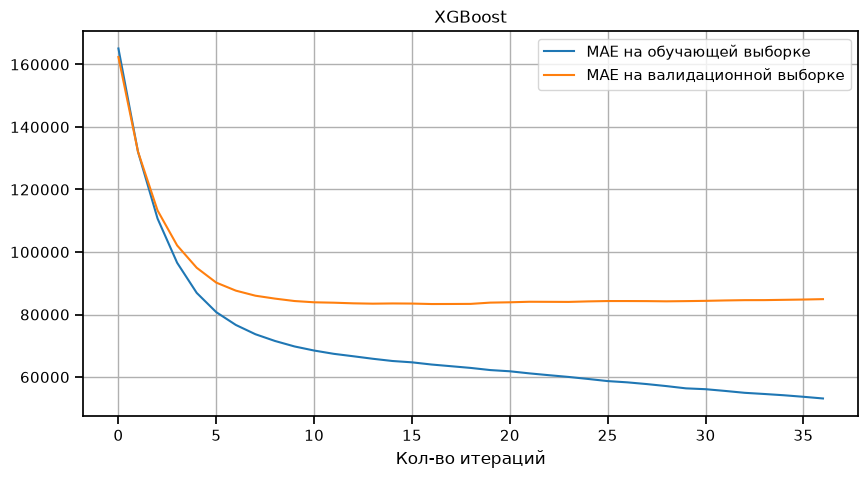

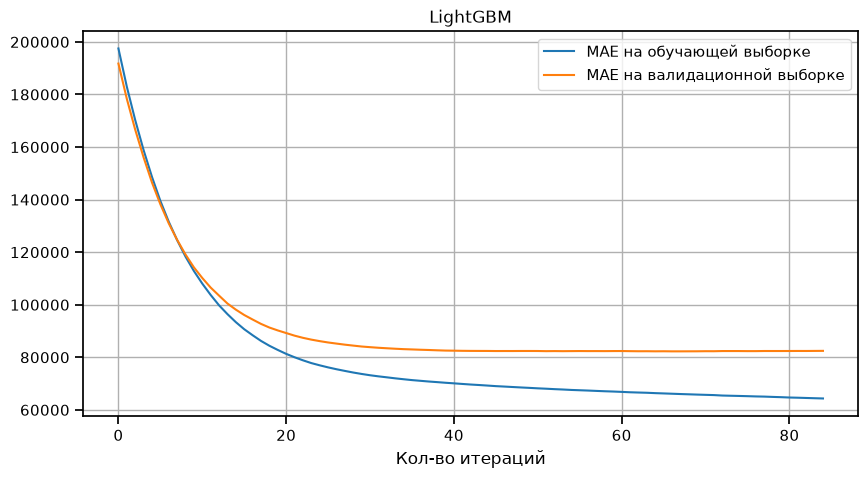

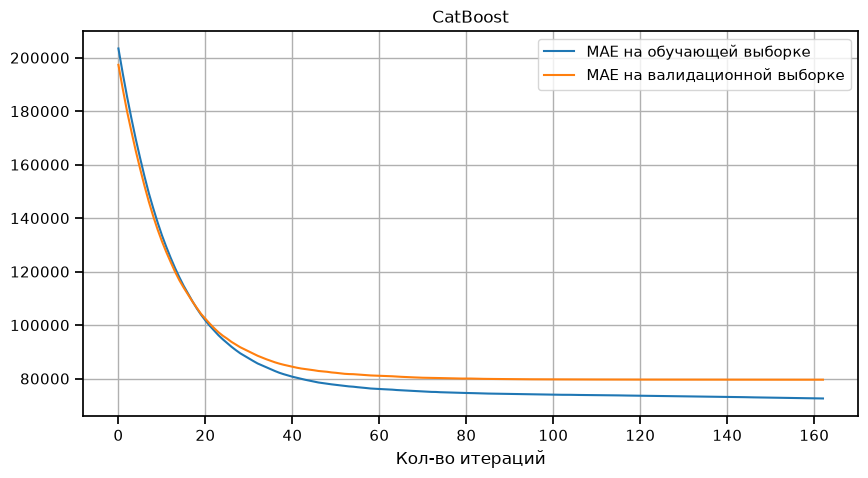

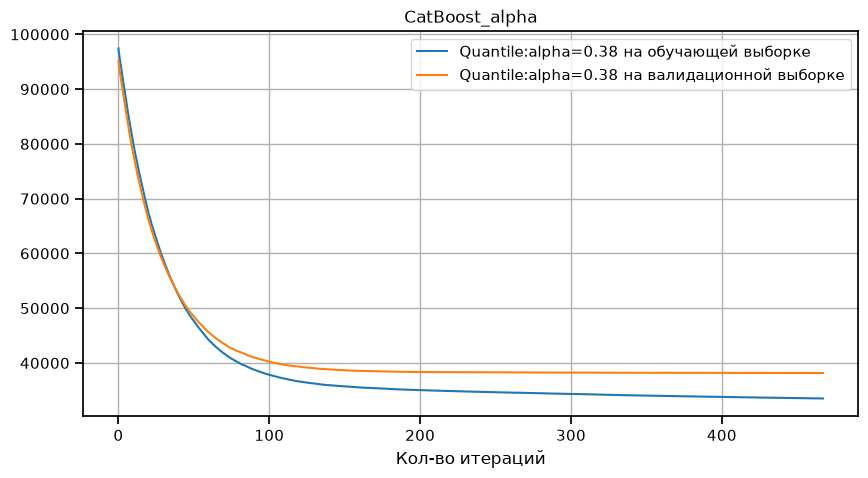

In [22]:
y1 = xgb_model.evals_result()['validation_0']['mae']
y2 = xgb_model.evals_result()['validation_1']['mae']
x = range(len(y1))
plot_MAE_train_val(x, y1, y2, (10, 5), 'MAE на обучающей выборке', 'MAE на валидационной выборке', 'XGBoost')

y1 = lgbm_model.evals_result_['training']['l1']
y2 = lgbm_model.evals_result_['valid_1']['l1']
x = range(len(y1))
plot_MAE_train_val(x, y1, y2, (10, 5), 'MAE на обучающей выборке', 'MAE на валидационной выборке', 'LightGBM')

y1 = catb_model.get_evals_result()['learn']['MAE']
y2 = catb_model.get_evals_result()['validation']['MAE']
x = range(len(y1))
plot_MAE_train_val(x, y1, y2, (10, 5), 'MAE на обучающей выборке', 'MAE на валидационной выборке', 'CatBoost')

y1 = catb_model_alpha.get_evals_result()['learn']['Quantile:alpha=0.38']
y2 = catb_model_alpha.get_evals_result()['validation']['Quantile:alpha=0.38']
x = range(len(y1))
plot_MAE_train_val(x, y1, y2, (10, 5), 'Quantile:alpha=0.38 на обучающей выборке', 'Quantile:alpha=0.38 на валидационной выборке', 'CatBoost_alpha')

**Выводы:**

1. Для всех четырех моделей, используя критерии ранней остановки по валидационной выборке, получены наилучшие результаты без переобучения. Это заметно по графикам зависимости метрики от количества итераций.
2. Наилучшие результаты по всем техническим метрикам (MAE, $R^2$, RMSE, MAPE, MSE) демонстрирует CatBoost. Однако, он является наиболее долго обучаемым. Предсказания он совершает достаточно быстро.
3. Наиболее быстрый алгоритм из предлагаемых - XGBoost. LightGBM близок к нему, но немного дольше обучается. CatBoost медленнее в 90 раз, хотя время обучения остается терпимым.
4. Создана дополнительная модель, штрафующая модель за отклонение от целевой переменной в большую сторону - `CatBoost_alpha`. Данная модель позволяет сократить прямые потери компании от переплаты за машины на 10 миллионов рублей (с 31.8 до 21.7). Ценой этому является то, что модель специально начинает снижать стоимость некоторые машины, что приводит к росту потерь у клиентов и, соответственно, росту `underpricing_loss`. Здесь стоит оговорится, что для компании это потенциальные потери. Рассчитать точные потери - сложно, т.к. неизвестно насколько отклонение цены от таргета в нижнюю сторону влияет на вероятность ухода клиента к конкуренту. Тем не менее `underpricing_loss` вырастает на 15 миллионов рублей у `CatBoost_alpha` по сравнению с обычным `CatBoost`.
5. В целом следует заметить, что все модели (исключение - `CatBoost_alpha`) за 20% порогом скорее склоны завысить стоимость, чем занизить ее. Это заметно при сравнении `underpricing_loss` и `overpricing_loss`, где заметно что `overpricing_loss` на валидации заметно выше, чем `underpricing_loss`.
6. Без дополнительных подборов параметров не смотря на некоторое ухудшение технических метрик `CatBoost_alpha` является предпочтительным вариантом по сравнению с остальными, т.к. помогает экономить бюджет компании. Попробуем улучшить метрики исходя из подбора гиперпараметров.

<a id='p5'></a>

---

## Подбор гиперпараметров модели

[К Содержимому проекта](#contents)

Подберем гиперпараметры модели используя `Optuna`. Сетка параметров соответствует указанным в [описании](#p2). Далее для каждой из четырех моделей проводится подборка гиперпараметров.

### `XGBoost`

In [23]:
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "gamma": trial.suggest_float('gamma', 1e-8, 1),
        "reg_alpha": trial.suggest_float('reg_alpha', 1e-8, 10),
        "reg_lambda": trial.suggest_float('reg_lambda', 1e-8, 10)
    }
    
    xgb_model = XGBRegressor(random_state=random_state,
                             enable_categorical=True,
                             eval_metric="mae",
                             early_stopping_rounds=20, # если 20 итераций подряд нет улучшения MAE на val — останавливаемся
                             n_jobs=-1,
                             **params
                            )
    
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_pred = xgb_model.predict(X_val)
    
    return mean_absolute_error(y_val, y_pred)

sampler = optuna.samplers.TPESampler(seed=random_state)
study_xgb = optuna.create_study(direction="minimize", sampler=sampler)
study_xgb.optimize(objective, n_trials=260, show_progress_bar=True)

[I 2026-10-07 17:05:14,570] A new study created in memory with name: no-name-9399eb98-05bd-4dcb-abb0-574f8211722b


  0%|          | 0/260 [00:00<?, ?it/s]

[I 2026-10-07 17:05:15,328] Trial 0 finished with value: 89079.1796875 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'gamma': 0.5986584882104518, 'reg_alpha': 1.5601864128641787, 'reg_lambda': 1.5599452118020811}. Best is trial 0 with value: 89079.1796875.
[I 2026-10-07 17:05:16,301] Trial 1 finished with value: 85611.71875 and parameters: {'learning_rate': 0.011430983876313222, 'max_depth': 9, 'n_estimators': 1402, 'gamma': 0.7080725807153198, 'reg_alpha': 0.2058449527521795, 'reg_lambda': 9.699098521920845}. Best is trial 1 with value: 85611.71875.
[I 2026-10-07 17:05:16,418] Trial 2 finished with value: 80427.375 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'gamma': 0.1834045180193887, 'reg_alpha': 3.0424224365529544, 'reg_lambda': 5.2475643210748135}. Best is trial 2 with value: 80427.375.
[I 2026-10-07 17:05:16,661] Trial 3 finished with value: 81271.703125 and parameters: {'learning_ra

[I 2026-10-07 17:05:26,983] Trial 27 finished with value: 80188.0 and parameters: {'learning_rate': 0.017395724429716906, 'max_depth': 3, 'n_estimators': 1858, 'gamma': 0.508903779816942, 'reg_alpha': 0.5154942758888403, 'reg_lambda': 1.5217449431282342}. Best is trial 26 with value: 80120.0390625.
[I 2026-10-07 17:05:27,585] Trial 28 finished with value: 80257.34375 and parameters: {'learning_rate': 0.01024571406182117, 'max_depth': 3, 'n_estimators': 1841, 'gamma': 0.6594136271248754, 'reg_alpha': 0.831881015586344, 'reg_lambda': 1.022271567369856}. Best is trial 26 with value: 80120.0390625.
[I 2026-10-07 17:05:27,994] Trial 29 finished with value: 81495.1171875 and parameters: {'learning_rate': 0.012116672464281348, 'max_depth': 5, 'n_estimators': 1688, 'gamma': 0.6492757660389984, 'reg_alpha': 1.5340671685558225, 'reg_lambda': 1.6786211921127105}. Best is trial 26 with value: 80120.0390625.
[I 2026-10-07 17:05:28,319] Trial 30 finished with value: 80566.7265625 and parameters: {'l

[I 2026-10-07 17:05:37,607] Trial 53 finished with value: 80082.1875 and parameters: {'learning_rate': 0.016901228553737328, 'max_depth': 3, 'n_estimators': 1964, 'gamma': 0.7475027022070626, 'reg_alpha': 1.5635167321773413, 'reg_lambda': 2.148206930756478}. Best is trial 44 with value: 80036.203125.
[I 2026-10-07 17:05:38,059] Trial 54 finished with value: 80447.0859375 and parameters: {'learning_rate': 0.012300192349484103, 'max_depth': 4, 'n_estimators': 1775, 'gamma': 0.6028814433377775, 'reg_alpha': 0.4697939002376333, 'reg_lambda': 1.8604518065083295}. Best is trial 44 with value: 80036.203125.
[I 2026-10-07 17:05:38,388] Trial 55 finished with value: 80077.9375 and parameters: {'learning_rate': 0.022842411674618777, 'max_depth': 3, 'n_estimators': 1960, 'gamma': 0.6921382743094555, 'reg_alpha': 1.1698746090108476, 'reg_lambda': 3.464281307765796}. Best is trial 44 with value: 80036.203125.
[I 2026-10-07 17:05:39,038] Trial 56 finished with value: 80119.6796875 and parameters: {'

...

[I 2026-10-07 17:06:02,812] Trial 131 finished with value: 80142.9921875 and parameters: {'learning_rate': 0.03130797469968383, 'max_depth': 3, 'n_estimators': 1979, 'gamma': 0.6876528111440121, 'reg_alpha': 0.9087036179132817, 'reg_lambda': 2.7441465769110516}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:03,088] Trial 132 finished with value: 80147.2421875 and parameters: {'learning_rate': 0.02501662837408985, 'max_depth': 3, 'n_estimators': 1996, 'gamma': 0.6408820841049852, 'reg_alpha': 2.4183542950695927, 'reg_lambda': 4.152674679937261}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:03,384] Trial 133 finished with value: 80061.5 and parameters: {'learning_rate': 0.023216702613991315, 'max_depth': 3, 'n_estimators': 1977, 'gamma': 0.6335979327650249, 'reg_alpha': 1.5095063289466493, 'reg_lambda': 2.3438542731564316}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:03,689] Trial 134 finished with value: 80133.3125 and paramete

[I 2026-10-07 17:06:10,782] Trial 157 finished with value: 80124.828125 and parameters: {'learning_rate': 0.024298137541584733, 'max_depth': 3, 'n_estimators': 1983, 'gamma': 0.6786981808763541, 'reg_alpha': 0.7863710898341347, 'reg_lambda': 2.412745068387625}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:11,044] Trial 158 finished with value: 80149.1015625 and parameters: {'learning_rate': 0.025397109809378534, 'max_depth': 3, 'n_estimators': 1972, 'gamma': 0.5910624403702186, 'reg_alpha': 0.9008126613216194, 'reg_lambda': 3.8905292895226986}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:11,296] Trial 159 finished with value: 80242.7890625 and parameters: {'learning_rate': 0.02956344368493255, 'max_depth': 3, 'n_estimators': 1986, 'gamma': 0.5999642292570606, 'reg_alpha': 1.4946007227042395, 'reg_lambda': 3.994784127451827}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:11,546] Trial 160 finished with value: 80275.078125 and p

[I 2026-10-07 17:06:19,006] Trial 183 finished with value: 79989.5625 and parameters: {'learning_rate': 0.0230603161021748, 'max_depth': 3, 'n_estimators': 1991, 'gamma': 0.6795869034193194, 'reg_alpha': 0.9306266265446322, 'reg_lambda': 3.2196134007090134}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:19,300] Trial 184 finished with value: 80249.8828125 and parameters: {'learning_rate': 0.022179093389460457, 'max_depth': 3, 'n_estimators': 1969, 'gamma': 0.6974509308334165, 'reg_alpha': 0.8125766574639031, 'reg_lambda': 3.1122346962103444}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:19,679] Trial 185 finished with value: 80088.6328125 and parameters: {'learning_rate': 0.02057043275950135, 'max_depth': 3, 'n_estimators': 1919, 'gamma': 0.658530477610284, 'reg_alpha': 0.8440156886709601, 'reg_lambda': 2.6478967154193693}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:19,928] Trial 186 finished with value: 80203.796875 and para

[I 2026-10-07 17:06:27,192] Trial 209 finished with value: 80149.3203125 and parameters: {'learning_rate': 0.025493529774449582, 'max_depth': 3, 'n_estimators': 1741, 'gamma': 0.6711904019963175, 'reg_alpha': 1.8840970430004882, 'reg_lambda': 2.9930457735974705}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:27,478] Trial 210 finished with value: 80107.2265625 and parameters: {'learning_rate': 0.026595535681417436, 'max_depth': 3, 'n_estimators': 1908, 'gamma': 0.6305912043841747, 'reg_alpha': 0.05797081605889798, 'reg_lambda': 3.5806377788216803}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:27,830] Trial 211 finished with value: 80187.28125 and parameters: {'learning_rate': 0.019197097848723706, 'max_depth': 3, 'n_estimators': 1855, 'gamma': 0.7176215667507577, 'reg_alpha': 1.3630506595586203, 'reg_lambda': 3.2010056905152746}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:28,087] Trial 212 finished with value: 80188.1015625 a

[I 2026-10-07 17:06:36,126] Trial 235 finished with value: 80179.75 and parameters: {'learning_rate': 0.025583953868141954, 'max_depth': 3, 'n_estimators': 1979, 'gamma': 0.6284111420786354, 'reg_alpha': 1.5658582528986802, 'reg_lambda': 4.074727985498904}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:36,461] Trial 236 finished with value: 80185.53125 and parameters: {'learning_rate': 0.023855575095366226, 'max_depth': 3, 'n_estimators': 1774, 'gamma': 0.7275267853328712, 'reg_alpha': 1.0915605781706115, 'reg_lambda': 2.808980918496974}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:36,841] Trial 237 finished with value: 80100.34375 and parameters: {'learning_rate': 0.02264148028442961, 'max_depth': 3, 'n_estimators': 1979, 'gamma': 0.5855589798756068, 'reg_alpha': 1.4263745177676697, 'reg_lambda': 2.844434884940151}. Best is trial 114 with value: 79964.3828125.
[I 2026-10-07 17:06:37,127] Trial 238 finished with value: 80253.484375 and parameters

Лучшие гиперпараметры: {'learning_rate': 0.024411038783799164, 'max_depth': 3, 'n_estimators': 1952, 'gamma': 0.6476940992458126, 'reg_alpha': 0.780158167827537, 'reg_lambda': 2.3189973908576755}
Лучшее значение MAE: 79964.3828125


C:\Users\EA\AppData\Local\Temp\ipykernel_24328\255882078.py:5: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_xgb)
C:\Users\EA\AppData\Local\Temp\ipykernel_24328\255882078.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_xgb)


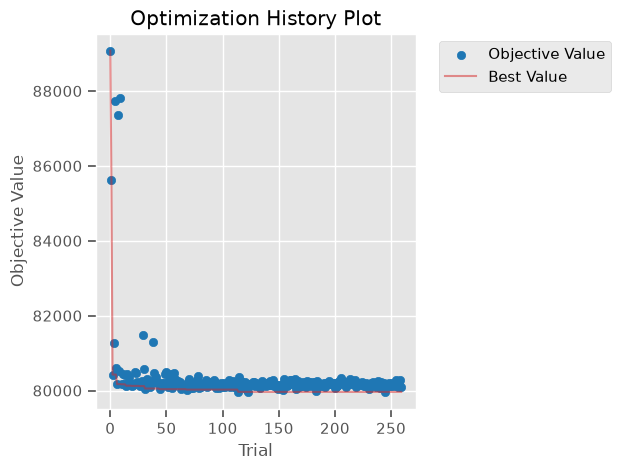

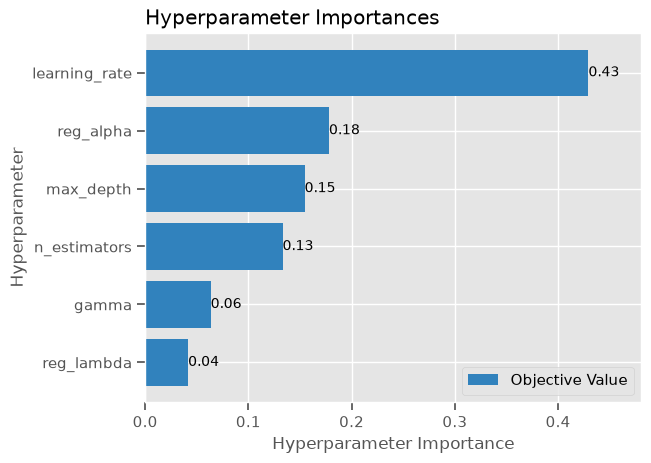

In [24]:
# Лучшие гиперпараметры и качество
print("Лучшие гиперпараметры:", study_xgb.best_params)
print("Лучшее значение MAE:", study_xgb.best_value)

plot_optimization_history(study_xgb)
plot_param_importances(study_xgb)
plt.show()

---

### `LightGBM`

In [25]:
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "num_leaves": trial.suggest_int('num_leaves', 20, 256),
        "min_child_samples": trial.suggest_int('min_child_samples', 5, 100),
        "reg_alpha": trial.suggest_float('reg_alpha', 1e-8, 10),
        "reg_lambda": trial.suggest_float('reg_lambda', 1e-8, 10)
    }
    lgbm_model = lgb.LGBMRegressor(random_state=random_state, 
                                   n_jobs=-1, verbose=-1, **params)
    
    lgbm_model.fit(X_train, y_train, eval_X=(X_val), eval_y=(y_val), eval_metric="mae", 
                   callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False), lgb.log_evaluation(period=0)])
    
    y_pred = lgbm_model.predict(X_val)
    
    return mean_absolute_error(y_val, y_pred)

sampler = optuna.samplers.TPESampler(seed=random_state)
study_lgbm = optuna.create_study(direction="minimize", sampler=sampler)
study_lgbm.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-10-07 17:06:45,438] A new study created in memory with name: no-name-90ffd5a0-7864-4da4-a8cc-73f38e8b2ccf


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-10-07 17:06:45,855] Trial 0 finished with value: 84247.01878940072 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'num_leaves': 161, 'min_child_samples': 19, 'reg_alpha': 1.5599452118020811, 'reg_lambda': 0.5808361311011585}. Best is trial 0 with value: 84247.01878940072.
[I 2026-10-07 17:06:45,930] Trial 1 finished with value: 81866.68949678839 and parameters: {'learning_rate': 0.07348118405270448, 'max_depth': 7, 'n_estimators': 1562, 'num_leaves': 24, 'min_child_samples': 98, 'reg_alpha': 8.324426409679791, 'reg_lambda': 2.1233911146593702}. Best is trial 1 with value: 81866.68949678839.
[I 2026-10-07 17:06:46,131] Trial 2 finished with value: 80632.90359607096 and parameters: {'learning_rate': 0.015199348301309814, 'max_depth': 4, 'n_estimators': 956, 'num_leaves': 144, 'min_child_samples': 46, 'reg_alpha': 2.9122914090681276, 'reg_lambda': 6.118528951105265}. Best is trial 2 with value: 80632.90359607096.
[I 2026-10-07 17:06:

[I 2026-10-07 17:06:49,532] Trial 26 finished with value: 81083.862216725 and parameters: {'learning_rate': 0.06263216496959757, 'max_depth': 5, 'n_estimators': 1740, 'num_leaves': 125, 'min_child_samples': 20, 'reg_alpha': 7.659789308878296, 'reg_lambda': 9.060426144558871}. Best is trial 11 with value: 79946.85309114274.
[I 2026-10-07 17:06:49,602] Trial 27 finished with value: 80803.62696181744 and parameters: {'learning_rate': 0.0581635430146764, 'max_depth': 4, 'n_estimators': 1516, 'num_leaves': 189, 'min_child_samples': 21, 'reg_alpha': 7.9656441123821455, 'reg_lambda': 7.838482375589742}. Best is trial 11 with value: 79946.85309114274.
[I 2026-10-07 17:06:49,670] Trial 28 finished with value: 80883.89050061579 and parameters: {'learning_rate': 0.07875549186068367, 'max_depth': 4, 'n_estimators': 1924, 'num_leaves': 142, 'min_child_samples': 10, 'reg_alpha': 9.604795889377913, 'reg_lambda': 9.717962496717043}. Best is trial 11 with value: 79946.85309114274.
[I 2026-10-07 17:06:4

Лучшие гиперпараметры: {'learning_rate': 0.03759870971063887, 'max_depth': 3, 'n_estimators': 1826, 'num_leaves': 173, 'min_child_samples': 23, 'reg_alpha': 9.28687501434858, 'reg_lambda': 8.594873029011584}
Лучшее значение MAE: 79938.72479198201


C:\Users\EA\AppData\Local\Temp\ipykernel_24328\331193385.py:5: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_lgbm)
C:\Users\EA\AppData\Local\Temp\ipykernel_24328\331193385.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_lgbm)


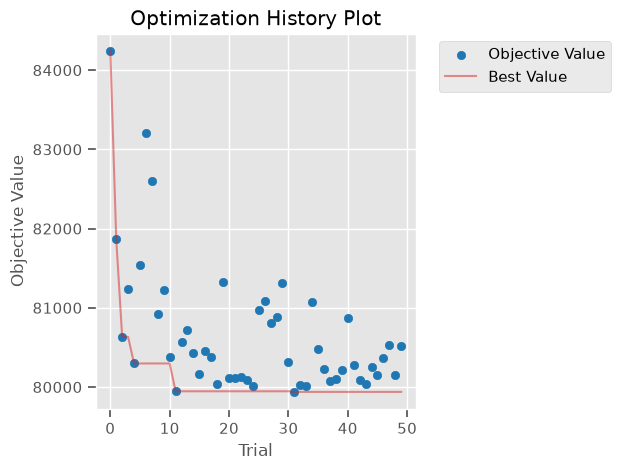

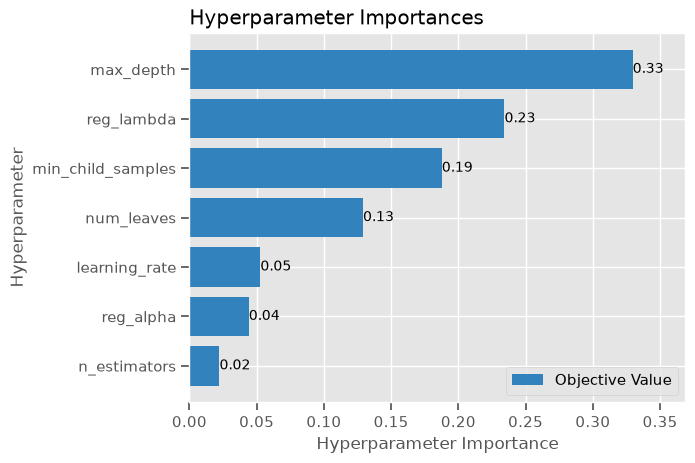

In [26]:
# Лучшие гиперпараметры и качество
print("Лучшие гиперпараметры:", study_lgbm.best_params)
print("Лучшее значение MAE:", study_lgbm.best_value)

plot_optimization_history(study_lgbm)
plot_param_importances(study_lgbm)
plt.show()

---

### `CatBoostRegressor`

In [27]:
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "l2_leaf_reg": trial.suggest_float('l2_leaf_reg', 1, 10)
    }
    catb_model = CatBoostRegressor(random_state=random_state, thread_count=-1, early_stopping_rounds=20,
                                   eval_metric='MAE', use_best_model=True, **params
                                  )
    
    catb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], cat_features=cat_list,
                   use_best_model=True, verbose=False)
    
    y_pred = catb_model.predict(X_val)
    
    return mean_absolute_error(y_val, y_pred)

sampler = optuna.samplers.TPESampler(seed=random_state)
study_catb = optuna.create_study(direction="minimize", sampler=sampler)
study_catb.optimize(objective, n_trials=15, show_progress_bar=True)

[I 2026-10-07 17:06:51,765] A new study created in memory with name: no-name-4bcacd3e-6f6c-484b-a3f5-2f5d44c2f070


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-10-07 17:07:09,859] Trial 0 finished with value: 79959.87314577396 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'l2_leaf_reg': 6.387926357773329}. Best is trial 0 with value: 79959.87314577396.
[I 2026-10-07 17:07:18,592] Trial 1 finished with value: 79583.07887240507 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 4, 'n_estimators': 587, 'l2_leaf_reg': 8.795585311974417}. Best is trial 1 with value: 79583.07887240507.
[I 2026-10-07 17:07:26,226] Trial 2 finished with value: 79945.24394052688 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 8, 'n_estimators': 530, 'l2_leaf_reg': 9.72918866945795}. Best is trial 1 with value: 79583.07887240507.
[I 2026-10-07 17:07:29,782] Trial 3 finished with value: 79439.24922762737 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'l2_leaf_reg': 2.650640588680904}. Best is trial 3 with value: 79439.24922762737.


Лучшие гиперпараметры: {'learning_rate': 0.03912141628549695, 'max_depth': 3, 'n_estimators': 1411, 'l2_leaf_reg': 2.5347171131856236}
Лучшее значение MAE: 79249.85518174453


C:\Users\EA\AppData\Local\Temp\ipykernel_24328\2636040567.py:5: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_catb)
C:\Users\EA\AppData\Local\Temp\ipykernel_24328\2636040567.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_catb)


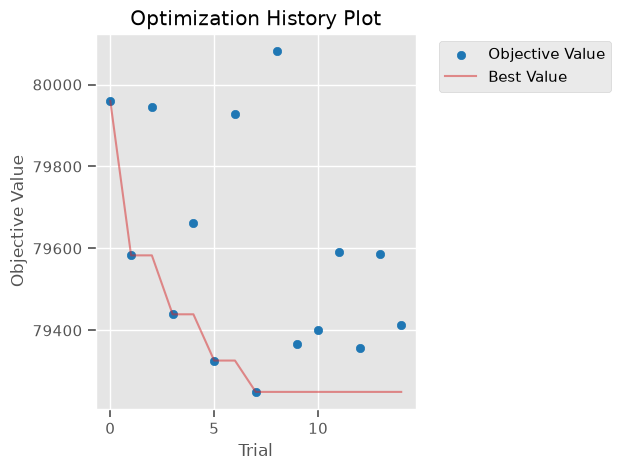

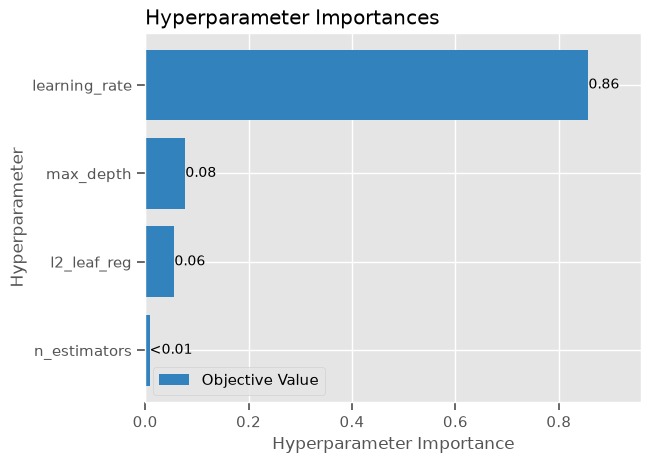

In [28]:
# Лучшие гиперпараметры и качество
print("Лучшие гиперпараметры:", study_catb.best_params)
print("Лучшее значение MAE:", study_catb.best_value)

plot_optimization_history(study_catb)
plot_param_importances(study_catb)
plt.show()

---

### `CatBoostRegressor_alpha`

In [29]:
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "l2_leaf_reg": trial.suggest_float('l2_leaf_reg', 1, 10)
    }
    catb_model_alpha = CatBoostRegressor(random_state=random_state, thread_count=-1, early_stopping_rounds=20,
                                         use_best_model=True, loss_function=f'Quantile:alpha={alpha}', 
                                         eval_metric=f'Quantile:alpha={alpha}', **params
                                        )
    
    catb_model_alpha.fit(X_train, y_train, eval_set=[(X_val, y_val)], cat_features=cat_list,
                         use_best_model=True, verbose=False)
    
    y_pred = catb_model_alpha.predict(X_val)
    
    return mean_absolute_error(y_val, y_pred)

sampler = optuna.samplers.TPESampler(seed=random_state)
study_catb_alpha = optuna.create_study(direction="minimize", sampler=sampler)
study_catb_alpha.optimize(objective, n_trials=32, show_progress_bar=True)

[I 2026-10-07 17:09:09,354] A new study created in memory with name: no-name-90804e41-2247-4356-bcee-10487b7681df


  0%|          | 0/32 [00:00<?, ?it/s]

[I 2026-10-07 17:09:25,317] Trial 0 finished with value: 83664.97598302436 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'l2_leaf_reg': 6.387926357773329}. Best is trial 0 with value: 83664.97598302436.
[I 2026-10-07 17:09:34,371] Trial 1 finished with value: 84081.3045731214 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 4, 'n_estimators': 587, 'l2_leaf_reg': 8.795585311974417}. Best is trial 0 with value: 83664.97598302436.
[I 2026-10-07 17:09:41,762] Trial 2 finished with value: 83951.21043729623 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 8, 'n_estimators': 530, 'l2_leaf_reg': 9.72918866945795}. Best is trial 0 with value: 83664.97598302436.
[I 2026-10-07 17:09:44,489] Trial 3 finished with value: 83760.03488332094 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'l2_leaf_reg': 2.650640588680904}. Best is trial 0 with value: 83664.97598302436.
[

[I 2026-10-07 17:14:41,615] Trial 31 finished with value: 83630.39098080175 and parameters: {'learning_rate': 0.01777395677198849, 'max_depth': 4, 'n_estimators': 1989, 'l2_leaf_reg': 8.263219146429858}. Best is trial 14 with value: 83521.99417580696.


Лучшие гиперпараметры: {'learning_rate': 0.09995148802832773, 'max_depth': 5, 'n_estimators': 804, 'l2_leaf_reg': 6.700479694381736}
Лучшее значение MAE: 83521.99417580696


C:\Users\EA\AppData\Local\Temp\ipykernel_24328\1218565293.py:5: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_catb_alpha)
C:\Users\EA\AppData\Local\Temp\ipykernel_24328\1218565293.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_catb_alpha)


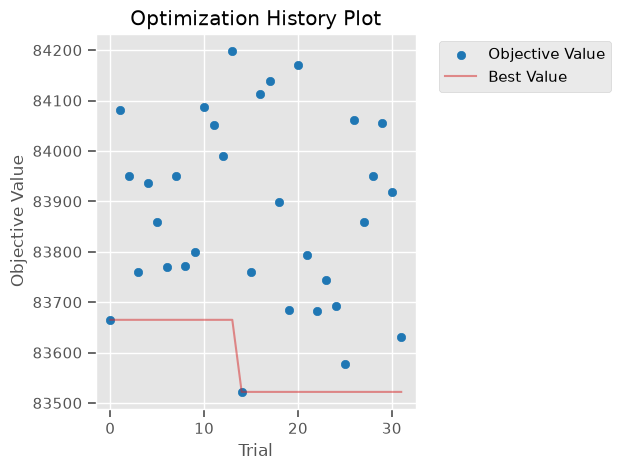

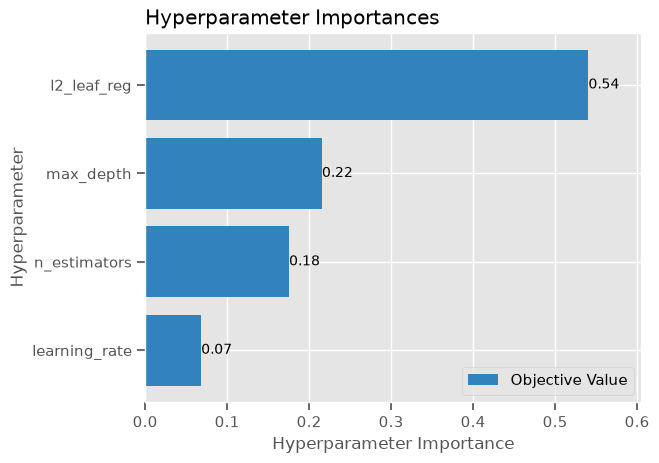

In [30]:
# Лучшие гиперпараметры и качество
print("Лучшие гиперпараметры:", study_catb_alpha.best_params)
print("Лучшее значение MAE:", study_catb_alpha.best_value)

plot_optimization_history(study_catb_alpha)
plot_param_importances(study_catb_alpha)
plt.show()

---

### Оптимизированные модели

In [31]:
xgb_model = XGBRegressor(random_state=random_state, enable_categorical=True, eval_metric="mae",
                         early_stopping_rounds=20, n_jobs=-1, **study_xgb.best_params)

lgbm_model = lgb.LGBMRegressor(random_state=random_state, n_jobs=-1, verbose=-1, **study_lgbm.best_params)
    
catb_model = CatBoostRegressor(random_state=random_state, thread_count=-1, early_stopping_rounds=20,
                               eval_metric='MAE', use_best_model=True, **study_catb.best_params)
    
catb_model_alpha = CatBoostRegressor(random_state=random_state, thread_count=-1, early_stopping_rounds=20,
                                     use_best_model=True, loss_function=f'Quantile:alpha={alpha}', 
                                     eval_metric=f'Quantile:alpha={alpha}', ** study_catb_alpha.best_params)

In [32]:
val_list = []
val_list = val_list + model_validate(xgb_model, X_train, y_train, X_val, y_val, 'XGBoost', 'Validation fold')
val_list = val_list + model_validate(lgbm_model, X_train, y_train, X_val, y_val, 'LightGBM', 'Validation fold')
val_list = val_list + model_validate(catb_model, X_train, y_train, X_val, y_val, 'CatBoost', 'Validation fold')
val_list = val_list + model_validate(catb_model_alpha, X_train, y_train, X_val, y_val, 'CatBoost_alpha', 'Validation fold')

display(pd.DataFrame(val_list).round(3).sort_values(by=['Fold name', 'MAE']))

,Model name,Fold name,Time elapsed fit,Time elapsed predict,overpricing_rate,underpricing_loss,overpricing_loss,MAE,R2,RMSE,MAPE,MSE
0,XGBoost,Train fold,0.342,0.013,0.129,4.977621e+07,1.104095e+08,70906.250,0.887,89380.815,13.108,7.988930e+09
2,LightGBM,Train fold,0.109,0.023,0.128,5.250025e+07,1.113273e+08,71608.729,0.885,90184.140,13.237,8.133179e+09
4,CatBoost,Train fold,6.169,0.006,0.135,5.764785e+07,1.195875e+08,74229.456,0.877,93343.331,13.703,8.712978e+09
6,CatBoost_alpha,Train fold,4.593,0.005,0.090,1.122286e+08,7.404892e+07,76143.014,0.867,96937.709,13.231,9.396919e+09
5,CatBoost,Validation fold,6.169,0.006,0.136,1.750254e+07,3.218340e+07,79249.855,0.855,98984.309,15.126,9.797893e+09
3,LightGBM,Validation fold,0.109,0.023,0.137,1.829706e+07,3.268454e+07,79938.725,0.852,100065.964,15.246,1.001320e+10
1,XGBoost,Validation fold,0.342,0.013,0.134,1.870169e+07,3.216144e+07,79964.383,0.852,100013.127,15.251,1.000263e+10
7,CatBoost_alpha,Validation fold,4.593,0.005,0.098,3.312188e+07,2.148839e+07,83521.994,0.840,103965.839,14.902,1.080890e+10


**Выводы:**

Подбор гиперпараметров немного улучшил итоговое состояние, но не кардинально. По итогу исходя из параметров на валидации будет взята модель `CatBoost_alpha`. Она помогает сэкономить на валидации около 11 мил. рублей переплат ценой 15 мил. упущенной выгоды у клиентов. Опять-таки не ясен размер рынка, как на самом деле влияют данные ошибки на финансовые показатели компании.

<a id='p6a'></a>

---

## Интерпретация и бизнес-анализ

### Анализ влияния признаков

[К Содержимому проекта](#contents)

Проведем анализ влияние признаков на предсказания для всех моделей. Для этого используем методику SHAP.

In [33]:
def plot_feature_figs(model, X_val, model_name='Unknown', figsize = (5,4)):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val)
    
    print(color.BOLD + color.BLUE + model_name + '\n' + color.END)
    # Summary Plot для всех признаков
    plt.figure(figsize=figsize)
    shap.summary_plot(shap_values, X_val, show=False)
    plt.title(f"SHAP Summary Plot для {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Bar plot — средние абсолютные SHAP-значения
    plt.figure(figsize=figsize)
    shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)
    plt.title(f"Глобальная важность признаков (средний |SHAP|) для {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print('\n\n')

XGBoost



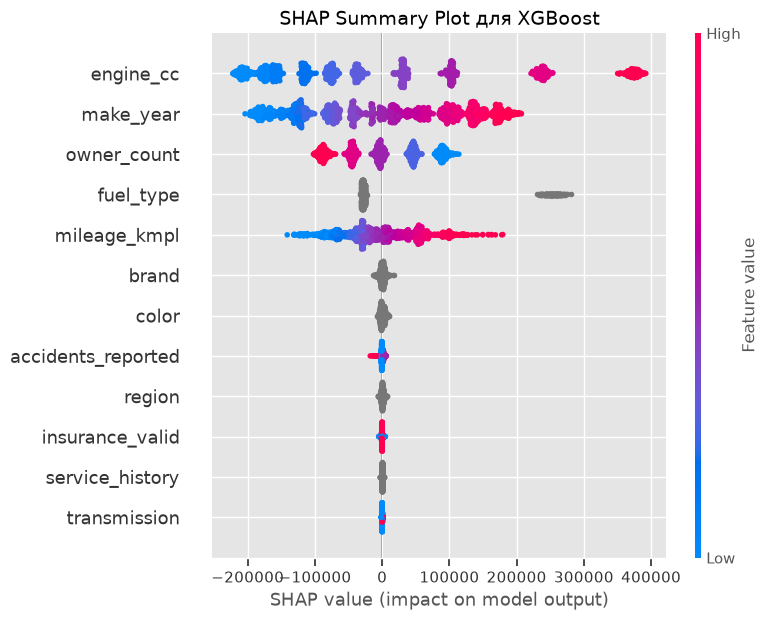

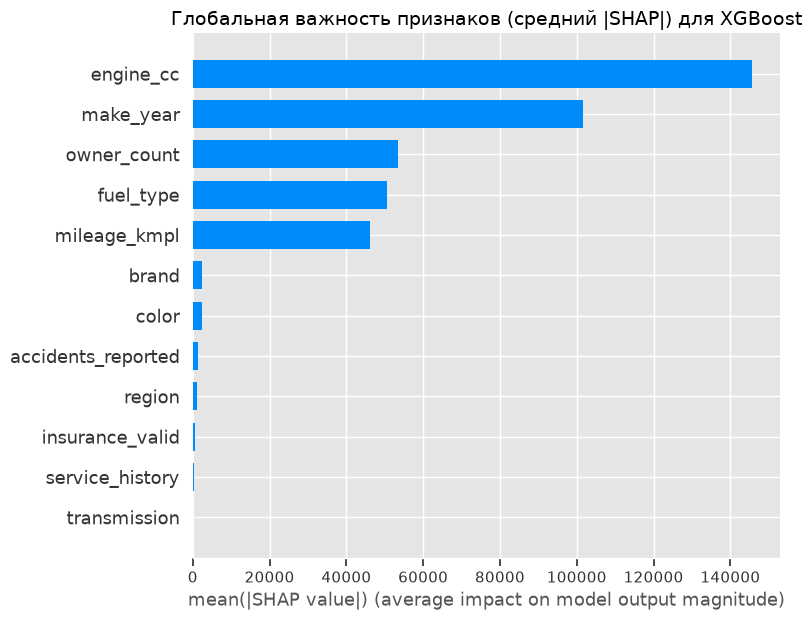




LightGBM



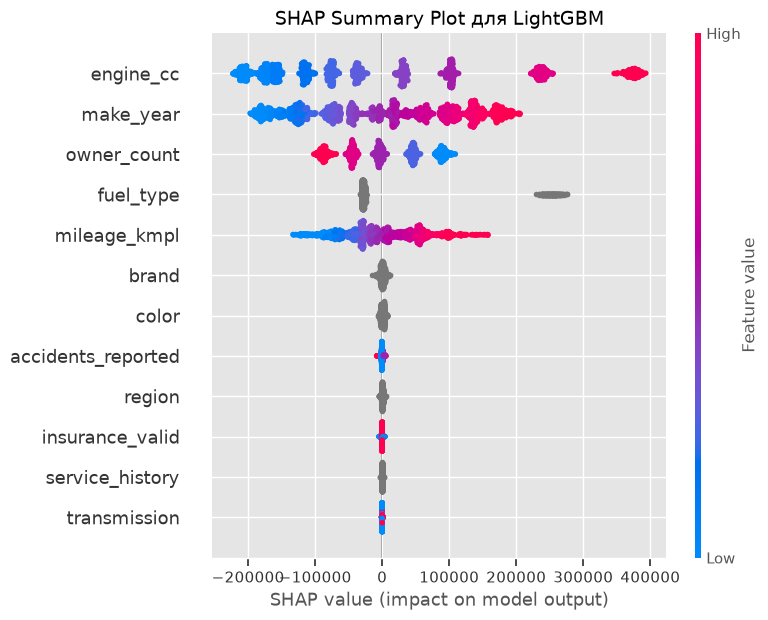

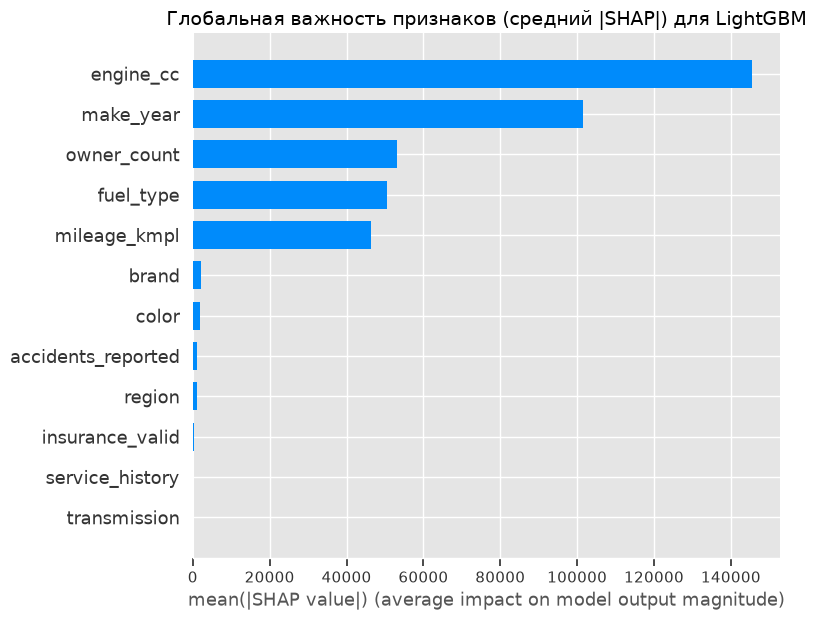




CatBoostRegressor



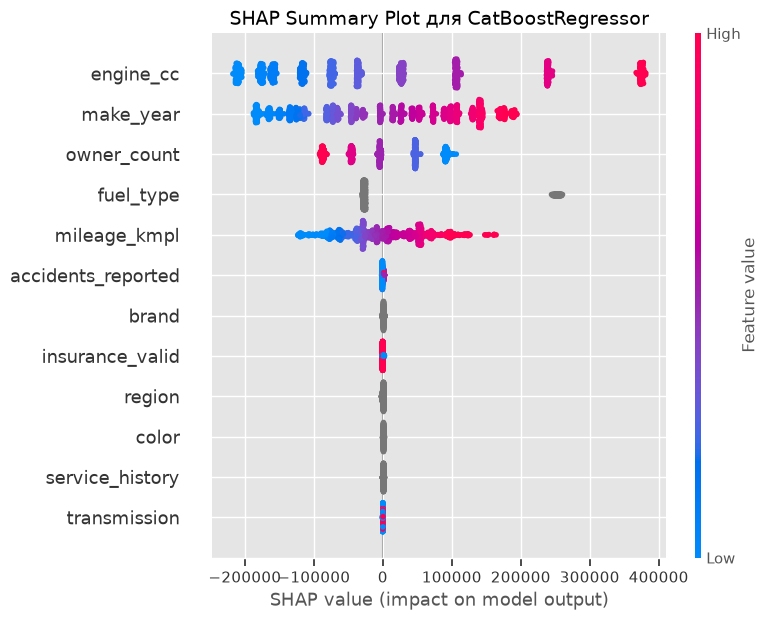

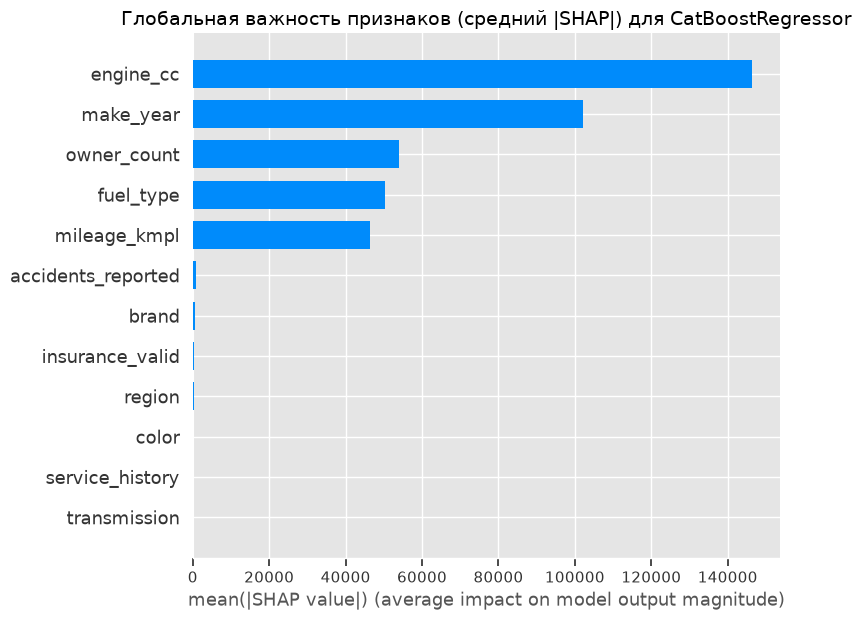




CatBoostRegressor_alpha



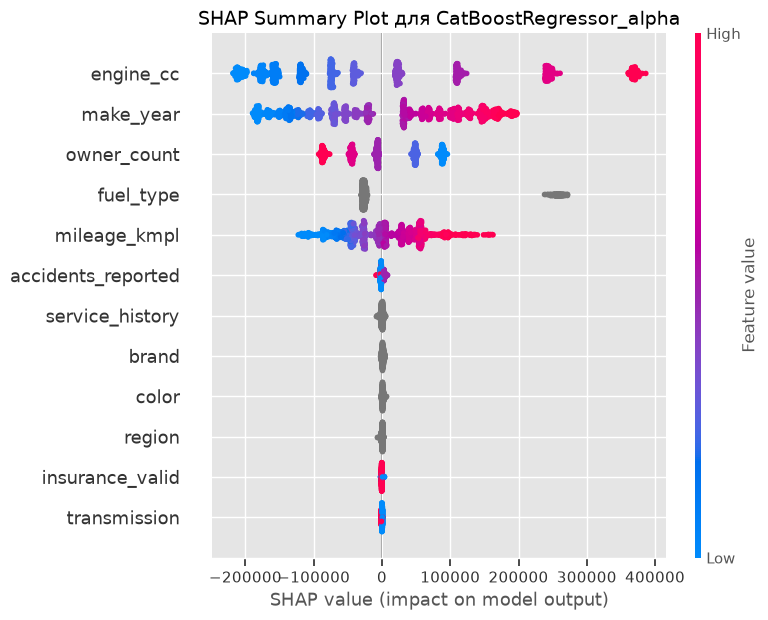

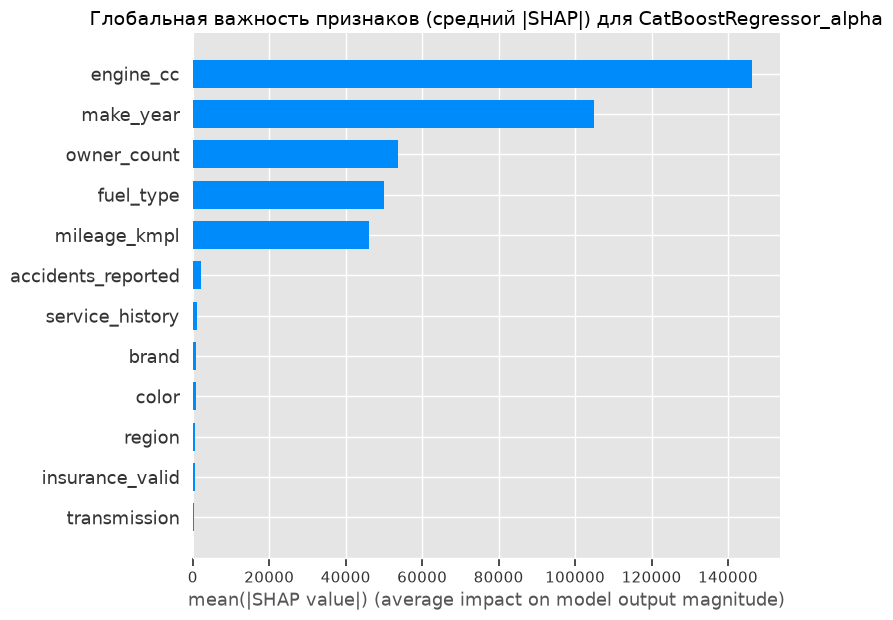

In [34]:
models = {'XGBoost' : xgb_model,
          'LightGBM': lgbm_model,
          'CatBoostRegressor': catb_model,
          'CatBoostRegressor_alpha': catb_model_alpha
         }

for name, model in models.items():
    plot_feature_figs(model, X_val, name)

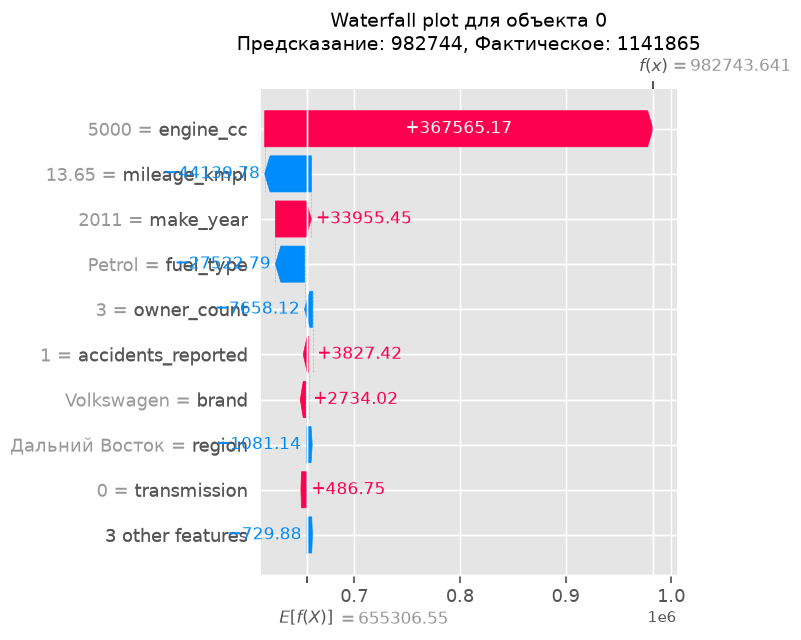

In [35]:
y_pred = catb_model_alpha.predict(X_val)
explainer = shap.TreeExplainer(catb_model_alpha)
shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap.Explanation(values=shap_values[0], 
                                    base_values=explainer.expected_value,
                                    data=X_val.iloc[0],
                                    feature_names=X_val.columns.tolist()),
                    max_display=10, show=False)
plt.title(f"Waterfall plot для объекта 0\nПредсказание: {y_pred[0]:.0f}, Фактическое: {y_val.iloc[0]:.0f}", fontsize=14)
plt.tight_layout()
plt.show()

**Выводы**:

Для всех моделей Топ-5 признаков выглядит одинаково:
1. `engine_cc` - объём двигателя;
2. `make_year` - год выпуска;
3. `owner_count` - количество владельцев;
4. `fuel_type` - тип топлива;
5. `mileage_kmpl` - пробег.

Остальные признаки для моделей не так важны и их важность зависит от того, про какую модель мы говорим. Например, шестым признаком по важности для моделей `CatBoost` является `accidents_reported`, а для моделей `XGBoost` и `LightGBM` является `brand`. В данном случае стоит отметить, что влияние остальных признаков незначительно. Кроме того, подобный результат был получен ранее при оценке корреляции через коэффициент $\varphi_k$, где также выделились эти пять признаков, а остальные близки к нулю. 

Из выделенных 5 признаков сильное положительное влияние (чем больше, тем больше цена) оказывают: объём двигателя, год выпуска, пробег. В последнем случае странно, т.к. влияние должно быть наоборот, но сами значения в данном столбце странные, так что здесь требуется более подробное описание расчета данного признака. Сильное отрицательное значение на стоимость оказывает `owner_count` (чем больше владельцев было, тем хуже). Влияние типа топлива не так важно, за исключением электромобилей, которые дороже. Данные наблюдения подтверждаются при оценке влияния признаков на цену для конкретного случайного пользователя, представленного выше.

<a id='p6b'></a>

---

### Анализ распределения ошибки по разным разным регионам и маркам

[К Содержимому проекта](#contents)


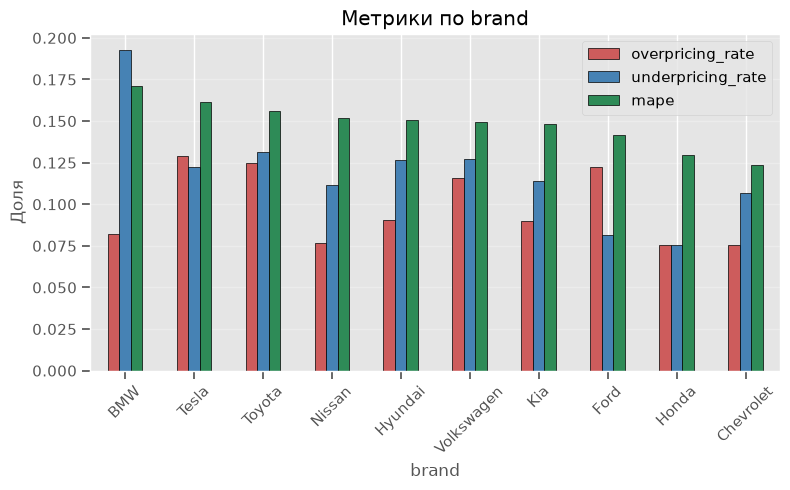

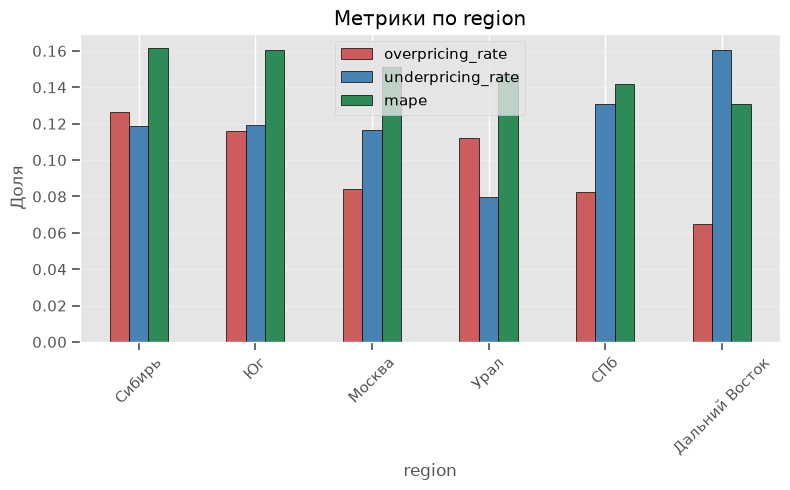

In [36]:
y_pred = catb_model_alpha.predict(X_val)
for col in ['brand', 'region']:
    val_list = X_val[col].unique()
    res_list = []
    
    for val in val_list:
        mask = (X_val[col] == val)
        error_ratio = (y_pred[mask] - y_val[mask]) / y_val[mask]
        overpricing = (error_ratio > 0.2).mean()
        underpricing = (error_ratio < -0.2).mean()
        mape = abs(error_ratio).mean()
        
        res_list.append({
            col : val,
            'overpricing_rate' : overpricing,
            'underpricing_rate' : underpricing,
            'mape' : mape
        })
    
    df_res = pd.DataFrame(res_list).set_index(col).sort_values(by = ['mape','overpricing_rate'], ascending = False)
    # display(df_res)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    df_res.plot(
        kind='bar', ax=ax, edgecolor='black',
        color=['indianred', 'steelblue', 'seagreen'], rot=45
    )
    ax.set_ylabel('Доля')
    ax.set_xlabel(col)
    ax.set_title(f'Метрики по {col}')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='best')
    
    plt.tight_layout()
    plt.show()

**Выводы**:

Здесь стоит отметить, что модель `CatBoostRegressor_alpha` в целом имеет смешение вниз из-за настроек по функции потерь. Она смещена вниз, т.е. в среднем имеет отрицательную ошибку. Однако, для бизнеса подобного рода смещения является более предпочтительным, поэтому была выбрана именно она. При анализе полученных результатов проблемными регионами или марками будем считать те, где наблюдается высокий разброс между `overpricing_rate` и `underpricing_rate` (в приоритете, если доминирует `overpricing_rate`, т.е. доля машин с завышенной моделью стоимостью более 20% выше доли с заниженной оценкой более 20%), а также заметен в целом высокий процент ошибки. Исходя из выбранного критерия можно выделить следующие марки:
1. `Ford` - модель часто переоценивает стоимость машин данной марки, при этом `mape` чуть ниже средних значений. Стоит проверять большие значения.
2. `BMW` - модель часто недооценивает машины данной марки, при этом `mape` максимальный среди всех марок. Стоит проверять сильно низкие значения.
3. `Tesla` - также стоит обращать внимание на данную марку, т.к. модель часто ошибается в среднем. Стоит данной марке в целом уделять особое значение.

Если проводить аналогичный анализ по регионам, то можно отметить следующее:
1. Машины на `Урале` модель склонна больше переоценивать, чем недооценивать. Стоит проверять большие значения оценки.
2. `Дальний восток` стоит проверять низкие значения стоимости машин.
3. `Сибирь` и `Юг` в целом стоит проверять результаты, полученные от модели в данных регионах.

<a id='p7'></a>

---

## Финальная модель

[К Содержимому проекта](#contents)

In [37]:
Type_Corrector_code = '''import pandas as pd

def Type_Corrector(X_train):
    X = X_train.copy()
    X['transmission'] = (X['transmission'] == 'Automatic').astype(int)
    X['insurance_valid'] = (X['insurance_valid'] == 'Yes').astype(int)
    
    for col in  X.select_dtypes(include = ['str','object']).columns.tolist():
        X[col] = X[col].astype('category')
    return X
'''
# Запись подпрограммы
try:
    Type_Corrector_path = "../src/Type_Corrector.py"
    with open(Type_Corrector_path, "w", encoding="utf-8") as f:
        f.write(Type_Corrector_code)
    
except Exception:
    Type_Corrector_path = "Type_Corrector.py"
    with open(Type_Corrector_path, "w", encoding="utf-8") as f:
        f.write(Type_Corrector_code)

# Считывание подпрограммы
try:
    sys.path.append("../src")
    from Type_Corrector import Type_Corrector
except Exception:
    from Type_Corrector import Type_Corrector

In [38]:
df_test = Type_Corrector(df_test)

X_test = df_test.drop(columns = ['price_rub']).copy()
y_test = df_test['price_rub']

try:
    joblib.dump(catb_model_alpha, '../models/Final_model.joblib')
except Exception:
    joblib.dump(catb_model_alpha, 'Final_model.joblib')

try:
    loaded_best = joblib.load('./../models/Final_model.joblib')
except Exception:
    loaded_best = joblib.load('Final_model.joblib')

y_pred_train = loaded_best.predict(X_train)
y_pred_valid = loaded_best.predict(X_val)
y_pred_test  = loaded_best.predict(X_test)

dict1 = {
    'Model name' : 'Final model',
    'Fold name' : 'train',
    **metrics_dict_calc(y_train, y_pred_train)
}
dict2 = {
    'Model name' : 'Final model',
    'Fold name' : 'valid',
    **metrics_dict_calc(y_val, y_pred_valid)
}
dict3 = {
    'Model name' : 'Final model',
    'Fold name' : 'test',
    **metrics_dict_calc(y_test, y_pred_test)
}

display(pd.DataFrame([ dict1, dict2, dict3 ]))

,Model name,Fold name,overpricing_rate,underpricing_loss,overpricing_loss,MAE,R2,RMSE,MAPE,MSE
0,Final model,train,0.090000,1.122286e+08,7.404892e+07,76143.014249,0.867252,96937.709178,13.231175,9.396919e+09
1,Final model,valid,0.098125,3.312188e+07,2.148839e+07,83521.994176,0.840402,103965.838575,14.901738,1.080890e+10
2,Final model,test,0.097000,3.694577e+07,2.476971e+07,78466.653444,0.864704,98560.037537,13.938237,9.714081e+09


**Выводы**

Итоговая модель `CatBoostRegressor_alpha` является досточно стабильной поскольку колебания метрик на всех фолдах не превышает 10%. Итоговые метрики на тесте:
1. `overpricing_rate = 9.7%` - доля машин, со стоимостью выше более чем в 20% от оптимальной, определенной экспертами.
2. `overpricing_loss = 25` мил. руб. - на столько суммарно переоценала модель машины клиентов при отклонении цены от экспертной цены.
3. `underpricing_loss = 37` мил. руб. - тоже, что выше, только недооценка.
4. В среднем модель ошибается на 78466 рублей при оценки машины, что в среднем составляет около 14% стоимости.

При построении модели `CatBoostRegressor_alpha` были использованы следующие гиперпараметры:
1. `random_state = 42` - фиксирует генератор случайных чисел для воспроизводимости результата. 
2. `thread_count = -1` - использовать все доступные ядра процессора для параллельного обучения.
3. `early_stopping_rounds = 20` - ранняя остановка: если выбранная метрика не улучшается 20 итераций подряд, обучение прекращается.
4. `use_best_model = True` - после обучения берётся модель с лучшим значением `eval_metric` на валидационной выборке, а не последняя итерация.
5. `loss_function = f'Quantile:alpha={alpha}'` - функция потерь для квантильной регрессии с уровнем alpha=0.38.
6. `eval_metric = f'Quantile:alpha={alpha}'` - метрика качества на валидации. Используется в том числе для early stopping. Здесь совпадает с функцией потерь.
7. `learning_rate = 0.09995` - скорость обучения. Определяет вклад каждого нового дерева в итоговый прогноз. Чем меньше значение, тем плавнее обучение, но тем больше деревьев может потребоваться.
8. `max_depth = 5` - максимальная глубина деревьев. Ограничивает сложность каждого дерева.
9. `n_estimators = 804` - максимальное количество деревьев (итераций бустинга). Из-за early_stopping_rounds фактическое число деревьев может быть меньше.
10. `l2_leaf_reg = 6.701` - коэффициент L2-регуляризации листьев. Чем выше значение, тем сильнее штраф за сложность листьев и тем устойчивее модель к переобучению.

Для улучшения качества модели стоит пересмотреть предоставляемые признаки. Большинство из них оказывает слабое влияние на целевую переменную. Имеющиеся тоже спорны, например, год выпуска. Данный признак важен для модели, но, возможно, в него неявным образом входят два разных: срок эксплуатации (время от момента производства машины и текущего момента) и модель автомобиля (например, Toyota Camry 2016 года выпуска и Toyota Camry 2020 года внешне крайне различные модели). Другой областью для улучшения может послужить рассмотрения других моделей - нейронные сети или случайный лес.

<a id='p8'></a>

---

## Аналитическая записка проекту AutoValue AI

[К Содержимому проекта](#contents)

**1. Рекомендованная модель:** 

`CatBoostRegressor_alpha` - квантильная регрессия на базе CatBoost с функцией потерь `Quantile:alpha=0.38`. Именно эта модель рекомендуется для внедрения в `AutoValue AI`, поскольку она обеспечивает лучший баланс между технической точностью и бизнес-рисками: снижает риск опасной переплаты при выкупе автомобилей.

**2. Точность оценки:**  

В среднем модель ошибается на 78 466 руб. `MAPE` составляет около 14% от стоимости автомобиля. Коэффициент детерминации: $R^2 = 0.86$. При `MAPE` $\approx$ `14%` можно ожидать приемлемый уровень $R^2$.

**3. Безопасность бюджета:**

Риск опасной переплаты `Overpricing Rate` - доля случаев, когда модель завысила цену более чем на 20%, - зафиксирован на уровне 9,7%. Суммарный `Overpricing Loss` на тестовой выборке составил около 25 млн руб. Это позволяет стартапу сохранять маржинальность при выкупе и ограничивать прямые финансовые потери от завышенных оценок.

**4. Упущенная выгода:**

`Underpricing Loss` - суммарная недооценка автомобилей более чем на 20% - на тестовой выборке составила около 37 млн руб. В пересчёте на месячный поток сделок значение нужно масштабировать пропорционально количеству сделок. Рекомендуется ручной пересмотр для премиум-сегмента, где недооценка особенно чувствительна для клиента и может привести к уходу к конкуренту.

**5. Зоны риска:**

По результатам бизнес-анализа модель наиболее нестабильна в следующих сегментах:
- **Регионы:**
  - `Урал` - модель чаще переоценивает автомобили, стоит проверять большие значения оценки;
  - `Дальний Восток` - чаще недооценивает, стоит проверять низкие значения;
  - `Сибирь` и `Юг` - в целом требуют дополнительного контроля качества прогнозов.
- **Марки:**
  - `Ford` - модель часто переоценивает стоимость, при этом `MAPE` чуть ниже среднего; проверять большие оценки;
  - `BMW` - модель часто недооценивает, при этом `MAPE` максимальный среди марок; проверять сильно низкие оценки;
  - `Tesla` - высокая средняя ошибка, марке стоит уделять особое внимание.

**6. Гиперпараметры для интеграции в мобильное приложение:**  

Для финальной модели `CatBoostRegressor_alpha` следует зафиксировать:
- `random_state = 42`;
- `thread_count = -1`;
- `early_stopping_rounds = 20`;
- `use_best_model = True`;
- `loss_function = 'Quantile:alpha=0.38'`;
- `eval_metric = 'Quantile:alpha=0.38'`;
- `learning_rate = 0.09995`;
- `max_depth = 5`;
- `n_estimators = 804`;
- `l2_leaf_reg = 6.701`.

<a id='p9'></a>

---

## Расширенные выводы и рекомендации

### Турнир библиотек

В рамках проекта были обучены и сравнены три библиотеки градиентного бустинга: `XGBoost`, `LightGBM` и `CatBoost`. Дополнительно была построена осторожная квантильная модель `CatBoostRegressor_alpha`.

По техническим метрикам лучшие результаты показал обычный `CatBoost`: у него оказались наилучшие значения `MAE`, `RMSE`, `R²`, `MAPE` и `MSE`. Однако `CatBoost` является самым медленным по времени обучения: он обучался примерно в 90 раз дольше, чем `XGBoost`, хотя время обучения оставалось приемлемым. `XGBoost` - самый быстрый, `LightGBM` близок к нему по скорости.

При этом по бизнес-метрикам предпочтительной оказалась модель `CatBoostRegressor_alpha`. Она немного уступает обычному `CatBoost` по техническим метрикам, но заметно снижает риск переплаты. На валидации `CatBoost_alpha` позволил сократить прямые потери компании от переплаты примерно с 31,8 млн руб. до 21,7 млн руб. Ценой этого стал рост `Underpricing Loss` примерно на 15 млн руб., поскольку модель специально чаще занижает цену. Для бизнеса такое смещение оказалось более предпочтительным: лучше недооценить часть автомобилей, чем систематически переплачивать при выкупе.

### Интерпретация модели через SHAP

SHAP-анализ показал, что для всех моделей топ-5 признаков выглядит одинаково:
1. `engine_cc` - объём двигателя;
2. `make_year` - год выпуска;
3. `owner_count` - количество владельцев;
4. `fuel_type` - тип топлива;
5. `mileage_kmpl` - пробег.

Остальные признаки влияют слабее. С точки зрения бизнес-логики:
- объём двигателя положительно связан с ценой: чем мощнее автомобиль, тем он обычно дороже;
- год выпуска также положительно влияет на цену, хотя сам признак спорный: он смешивает возраст автомобиля и поколение модели;
- количество владельцев отрицательно влияет на стоимость: чем больше владельцев, тем дешевле автомобиль;
- тип топлива влияет слабее, но электромобили в среднем дороже;
- `mileage_kmpl` показывает положительную связь с ценой, что противоречит привычной логике «больше пробег — ниже цена». Это означает, что признак требует уточнения у заказчика: непонятно, в каких единицах он измеряется и как рассчитывается.

### Бизнес-выводы

Итоговая модель `CatBoostRegressor_alpha` является достаточно стабильной: колебания метрик на всех фолдах не превышают 10%. На тестовой выборке получены следующие результаты:
- `Overpricing Rate = 9,7%`;
- `Overpricing Loss = 25 млн руб.`;
- `Underpricing Loss = 37 млн руб.`;
- средняя ошибка - 78 466 руб., что составляет около 14% стоимости автомобиля.

Модель склонна к небольшому смещению вниз из-за квантильной функции потерь. Для бизнеса это скорее плюс: компания реже переплачивает при выкупе. Однако часть автомобилей будет оцениваться ниже рынка, что может повышать риск ухода клиента к конкуренту. Особенно это касается премиум-сегмента и проблемных марок: `BMW`, `Tesla`, а также `Ford` - в случае переоценки.

### Финальный вердикт

Для внедрения в `AutoValue AI` рекомендуется модель:

**`CatBoostRegressor_alpha` с `loss_function='Quantile:alpha=0.38'`.**

Она не является абсолютным лидером по `MAE` и `R²`, но даёт лучший бизнес-компромисс: снижает риск опасной переплаты, остаётся достаточно стабильной и лучше соответствует финансовым ограничениям проекта.

Рекомендации по дальнейшей работе:

1. Для зон риска - `Урал`, `Дальний Восток`, `Сибирь`, `Юг`, а также марок `Ford`, `BMW`, `Tesla` - предусмотреть ручной пересмотр оценок.
2. Регулярно мониторить `Overpricing Rate`, `Overpricing Loss`, `Underpricing Loss`, `MAE` и `MAPE`.
3. Уточнить у заказчика смыслы некоторыз признаков.
4. Рассмотреть добавление новых признаков.
5. Периодически пересматривать гиперпараметры и порог квантиля `alpha`, если распределение цен или поведение рынка изменится.

Таким образом, проект позволил построить воспроизводимый пайплайн оценки стоимости подержанных автомобилей и выбрать модель, которая обеспечивает приемлемую точность и контролируемый уровень бизнес-рисков для сервиса `AutoValue AI`.

Проект опубликован и доступен для скачивания по ссылке:

https://github.com/AlexandrEvdokimov/AutoValue_AI-_Smart_Car_Valuation